# Customer Trends & Diagnostics EDA

This notebook is split from `02_customer_behavior.ipynb` for maintainability.


In [1]:
import importlib
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# --- Display formatting (readable numbers in notebook output) ---
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# --- Notebook output controls (clean vs verbose mode) ---
SHOW_VERBOSE_TABLES = False
PREVIEW_ROWS = 10

def show_df(df, title=None, n=PREVIEW_ROWS):
    """Display full table only in verbose mode; otherwise show top-N preview."""
    if title:
        print(title)
    display(df if SHOW_VERBOSE_TABLES else df.head(n))

# --- Configuration ---
# set USE_SAMPLE = True for quick testing, False for full dataset analysis
USE_SAMPLE = False

# Setup project path
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists() and (parent / "data").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Reload the loader module so notebook execution always uses the latest code.
import instacart_quality.data_access as data_access_module
importlib.reload(data_access_module)

df = data_access_module.load_customer_behavior_data(
    use_sample=USE_SAMPLE,
    project_root=PROJECT_ROOT,
)


## RFM Segments (Reorder time)

# 1) Customer Segmentation Value Analysis

แบ่งลูกค้าออกเป็นกลุ่มตามพฤติกรรม แล้วประมาณ **มูลค่าสัมพัทธ์** ของแต่ละกลุ่มผ่าน Value Index

| ขั้นตอน | รายละเอียด |
|---------|-----------|
| 1.1 | สร้าง User Segment (Whales / Regulars / Churned) |
| 1.2 | กำหนด Value Weight ตาม Aisle → คำนวณ Value Index |
| 1.3 | Spending Intensity & Segment Strategy Map |

สร้างกลุ่มลูกค้าจาก **User-level features** เพื่อวิเคราะห์ "ความต่าง" ของพฤติกรรมให้ชัดขึ้น

Features หลัก:
- `total_orders` = จำนวนครั้งที่สั่งซื้อ
- `avg_basket_size` = จำนวนสินค้าเฉลี่ยต่อตะกร้า
- `reorder_ratio` = อัตราการซื้อซ้ำ
- `days_since_last_order` = วันตั้งแต่สั่งครั้งล่าสุด

Logic การแบ่ง Segment (แบบเรียบง่ายและตีความง่าย):
- **Whales**: ลูกค้าที่สั่งบ่อยมาก (`total_orders` อยู่ใน Top 10%)
- **Regulars**: ลูกค้าทั่วไป
- **Churned**: ลูกค้าที่ไม่ได้สั่งมานานเกิน 30 วัน

หมายเหตุ: ถ้าลูกค้าเข้าเงื่อนไข Churned จะถูกจัดเป็น `Churned` แม้จะเคยสั่งบ่อย (override เพื่อเน้นสถานะล่าสุด)

In [2]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

# 1) Order frequency + reorder behavior + recency per user
user_order_profile = (
    df.groupby("user_id", observed=False)
    .agg(
        total_orders=("order_id", "nunique"),
        reorder_ratio=("reordered", "mean"),
        last_order_date=("order_date", "max"),
    )
    .reset_index()
)

# 2) Basket size per order -> average basket size at user level
order_basket = (
    df.groupby(["user_id", "order_id"], observed=False)
    .agg(basket_size=("product_id", "count"))
    .reset_index()
)

user_basket_profile = (
    order_basket.groupby("user_id", observed=False)
    .agg(avg_basket_size=("basket_size", "mean"))
    .reset_index()
)

# Keep variable name `rfm` for downstream compatibility in this notebook.
rfm = user_order_profile.merge(user_basket_profile, on="user_id", how="left")
rfm["days_since_last_order"] = (snapshot_date - rfm["last_order_date"]).dt.days

# Segment rules
whale_threshold = rfm["total_orders"].quantile(0.90)
rfm["segment"] = "Regulars"
rfm.loc[rfm["total_orders"] >= whale_threshold, "segment"] = "Whales"
rfm.loc[rfm["days_since_last_order"] > 30, "segment"] = "Churned"

segment_order = ["Whales", "Regulars", "Churned"]
rfm["segment"] = pd.Categorical(rfm["segment"], categories=segment_order, ordered=True)

## Trend & Time-Series Analysis ล่าสุด 12 เดือน

## 6) Trend, Seasonality & Cohort Diagnostics

คำถามธุรกิจที่ตอบในส่วนนี้:
1. ยอดสั่งซื้อและจำนวนลูกค้า active เปลี่ยนไปอย่างไรในช่วงเวลา
2. มีช่วง peak period แบบรายเดือนหรือรายสัปดาห์ตรงไหนบ้าง
3. ลูกค้าแต่ละ cohort ยังกลับมาซื้อซ้ำอยู่หรือไม่ และ spend ลดลง/เพิ่มขึ้นอย่างไรเมื่อเวลาผ่านไป

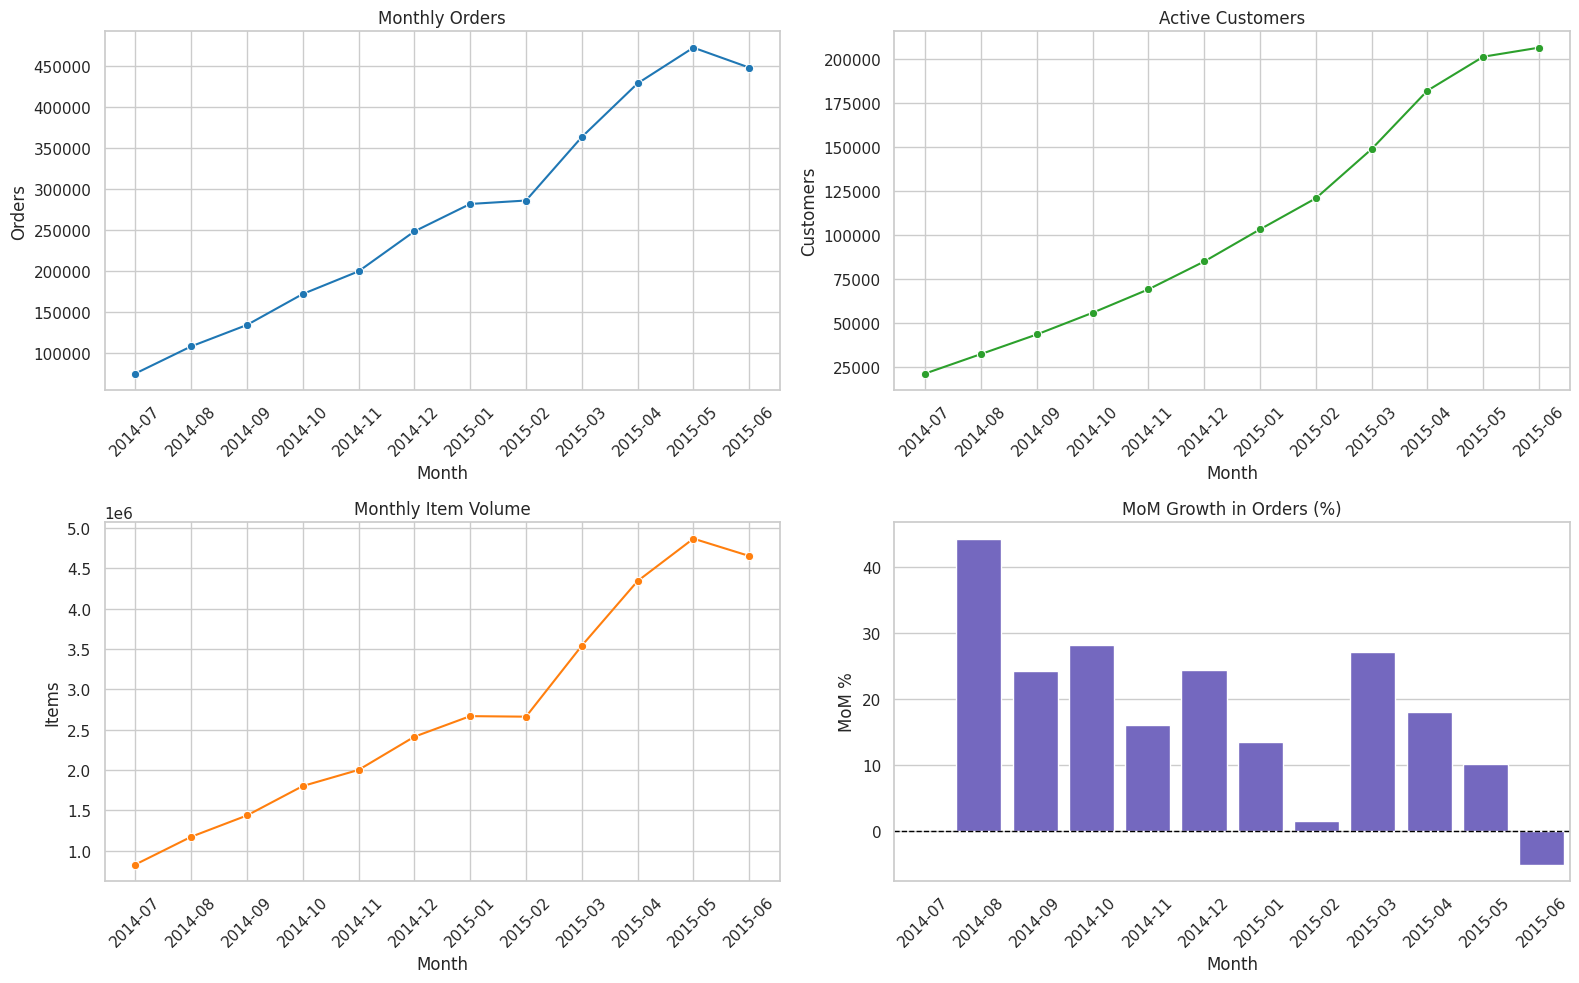

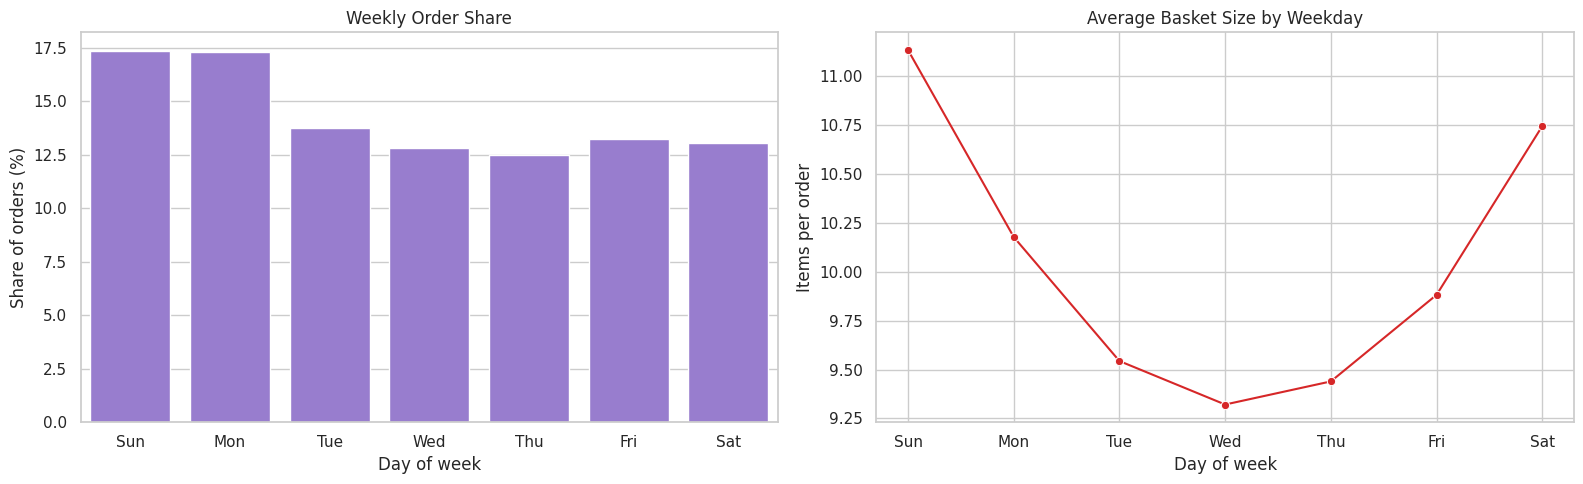

Trend summary
- Peak month by orders: May 2015 (471,794 orders, 201,055 active customers)
- Strongest MoM order growth: Aug 2014 (44.4%)
- Softest MoM order growth: Jun 2015 (-5.2%)
- Peak weekday: Sun (17.3% of all orders)
- Jul 2015 was excluded from monthly growth charts because data only runs through 2015-07-01.
- YoY is mostly unavailable because the dataset spans only about one annual cycle.
Monthly KPI trend snapshot (latest complete months):


,order_month,active_customers,total_orders,total_items,orders_per_customer,items_per_order,total_orders_mom_pct,active_customers_mom_pct,total_items_mom_pct,total_orders_yoy_pct
0,2014-07-01,21549,74544,830110,3.459279,11.135839,NaN,NaN,NaN,NaN
1,2014-08-01,32586,107629,1173850,3.302922,10.906447,44.383183,51.218154,41.408970,NaN
2,2014-09-01,43688,133745,1438065,3.061367,10.752290,24.264836,34.069846,22.508412,NaN
3,2014-10-01,55984,171493,1802871,3.063250,10.512796,28.223859,28.145028,25.367838,NaN
4,2014-11-01,69250,199130,2002730,2.875523,10.057400,16.115527,23.696056,11.085596,NaN
5,2014-12-01,85038,247811,2414091,2.914121,9.741662,24.446844,22.798556,20.540013,NaN
6,2015-01-01,103250,281255,2669130,2.724019,9.490071,13.495769,21.416308,10.564598,NaN
7,2015-02-01,120843,285425,2662612,2.361949,9.328587,1.482640,17.039225,-0.244199,NaN
8,2015-03-01,148737,362823,3541997,2.439359,9.762328,27.116756,23.082843,33.027155,NaN
9,2015-04-01,181852,428206,4343481,2.354695,10.143438,18.020633,22.264131,22.628026,NaN


Weekly seasonality snapshot:


,weekday,total_orders,order_share_pct,items_per_order
0,Sun,557772,17.349731,11.132983
1,Mon,556705,17.316542,10.177484
2,Tue,441955,13.747195,9.543501
3,Wed,412400,12.827874,9.321331
4,Thu,401212,12.479867,9.439436
5,Fri,425982,13.250348,9.881950
6,Sat,418848,13.028442,10.744480


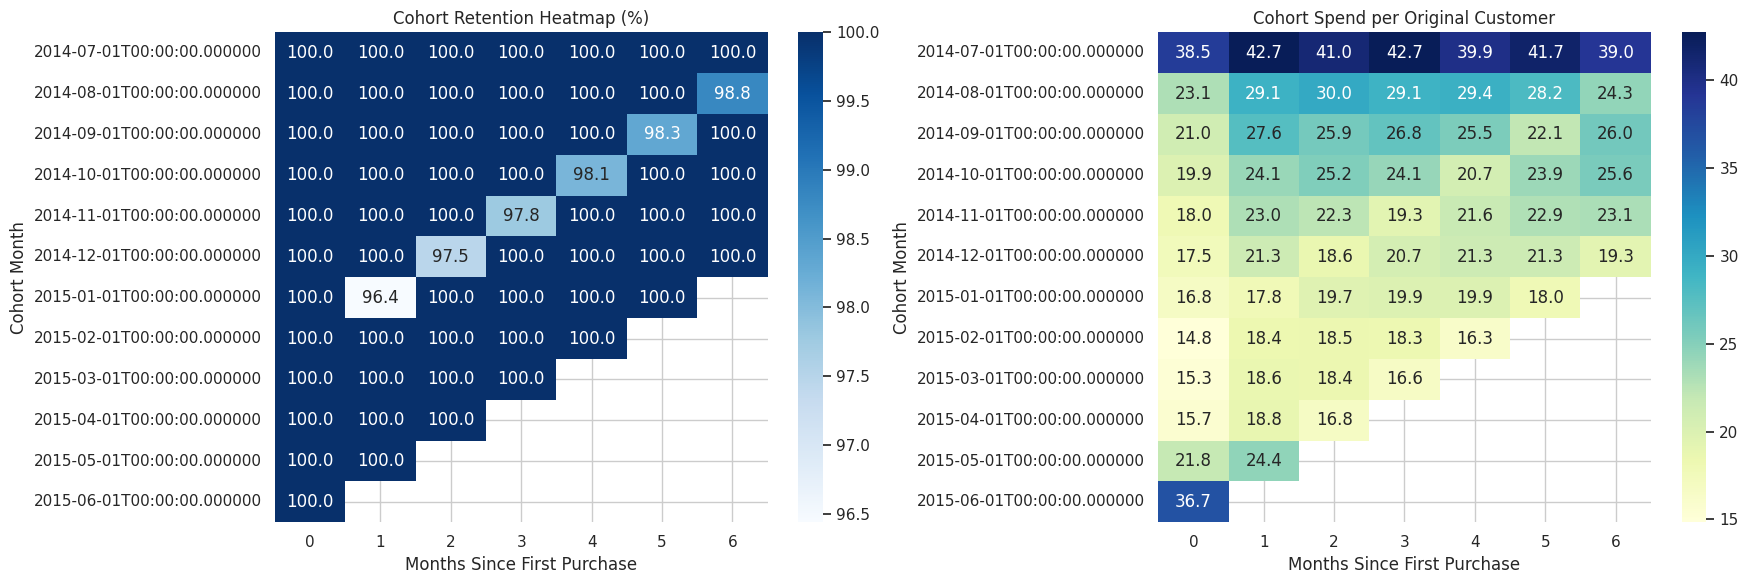

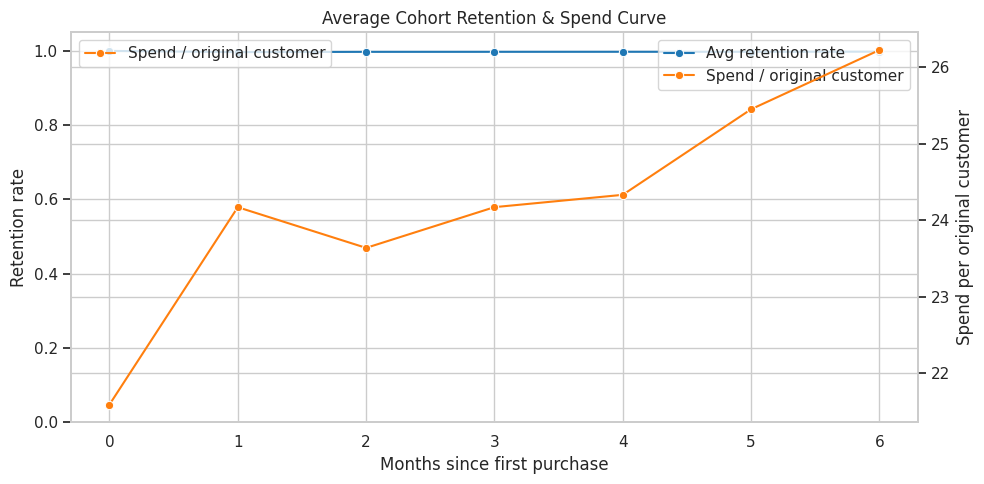

Cohort retention & spend snapshot:


,cohort_month,retention_rate_m0,retention_rate_m1,retention_rate_m3,retention_rate_m6,spend_per_original_customer_m0,spend_per_original_customer_m1,spend_per_original_customer_m3,spend_per_original_customer_m6,spend_change_m3_vs_m0_pct
0,2014-07-01,1.0,1.000000,1.000000,1.00000,38.521973,42.652838,42.703699,39.023899,10.855429
1,2014-08-01,1.0,1.000000,1.000000,0.98795,23.079098,29.133188,29.063514,24.316662,25.930026
2,2014-09-01,1.0,1.000000,1.000000,1.00000,20.986669,27.597820,26.842731,25.982616,27.903723
3,2014-10-01,1.0,1.000000,1.000000,1.00000,19.946893,24.064167,24.124675,25.587183,20.944522
4,2014-11-01,1.0,1.000000,0.977838,1.00000,18.006935,23.027288,19.326700,23.121061,7.329203
5,2014-12-01,1.0,1.000000,1.000000,1.00000,17.540917,21.284710,20.700405,19.293387,18.012104
6,2015-01-01,1.0,0.964364,1.000000,NaN,16.763013,17.821272,19.898199,NaN,18.702995
7,2015-02-01,1.0,1.000000,1.000000,NaN,14.841599,18.429799,18.278505,NaN,23.157246
8,2015-03-01,1.0,1.000000,1.000000,NaN,15.262949,18.643488,16.587527,NaN,8.678393
9,2015-04-01,1.0,1.000000,NaN,NaN,15.675796,18.770436,NaN,NaN,NaN


NameError: name 'rfm' is not defined

In [3]:
# --- Trend, seasonality, growth, and cohort diagnostics ---
CLV_FREQ = "M"
MAX_MONTH_INDEX = 6

order_value = (
    df.groupby(["user_id", "order_id", "order_date", "order_dow"], observed=False)
    .agg(order_value=("total_price", "sum"))
    .reset_index()
)
order_value["order_month"] = order_value["order_date"].dt.to_period(CLV_FREQ).dt.to_timestamp()

customer_monthly = (
    order_value.groupby(["user_id", "order_month"], observed=False)
    .agg(monthly_spend=("order_value", "sum"))
    .reset_index()
    .sort_values(["user_id", "order_month"])
)
customer_monthly["cumulative_clv"] = customer_monthly.groupby("user_id", observed=False)["monthly_spend"].cumsum()

# 1) Monthly trend + growth metrics
monthly_kpis = (
    order_value.groupby("order_month", observed=False)
    .agg(
        active_customers=("user_id", "nunique"),
        total_orders=("order_id", "nunique"),
        total_items=("order_value", "sum"),
    )
    .reset_index()
    .sort_values("order_month")
)
monthly_kpis["orders_per_customer"] = monthly_kpis["total_orders"] / monthly_kpis["active_customers"]
monthly_kpis["items_per_order"] = monthly_kpis["total_items"] / monthly_kpis["total_orders"]

latest_order_date = df["order_date"].max()
latest_month = latest_order_date.to_period(CLV_FREQ).to_timestamp()
exclude_partial_month = (
    latest_month == monthly_kpis["order_month"].max()
    and latest_order_date.day <= 7
)

trend_monthly = (
    monthly_kpis[monthly_kpis["order_month"] < latest_month].copy()
    if exclude_partial_month
    else monthly_kpis.copy()
)

for col in ["active_customers", "total_orders", "total_items", "orders_per_customer", "items_per_order"]:
    trend_monthly[f"{col}_mom_pct"] = trend_monthly[col].pct_change() * 100
    trend_monthly[f"{col}_yoy_pct"] = trend_monthly[col].pct_change(12) * 100

recent_monthly = trend_monthly.tail(12).copy()
recent_monthly["month_label"] = recent_monthly["order_month"].dt.strftime("%Y-%m")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.lineplot(
    data=recent_monthly,
    x="month_label",
    y="total_orders",
    marker="o",
    ax=axes[0, 0],
    color="tab:blue",
)
axes[0, 0].set_title("Monthly Orders")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Orders")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=recent_monthly,
    x="month_label",
    y="active_customers",
    marker="o",
    ax=axes[0, 1],
    color="tab:green",
)
axes[0, 1].set_title("Active Customers")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Customers")
axes[0, 1].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=recent_monthly,
    x="month_label",
    y="total_items",
    marker="o",
    ax=axes[1, 0],
    color="tab:orange",
)
axes[1, 0].set_title("Monthly Item Volume")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Items")
axes[1, 0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=recent_monthly,
    x="month_label",
    y="total_orders_mom_pct",
    ax=axes[1, 1],
    color="slateblue",
)
axes[1, 1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1, 1].set_title("MoM Growth in Orders (%)")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("MoM %")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# 2) Weekly seasonality snapshot
weekday_map = {0: "Sun", 1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"}
weekday_order = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

weekday_seasonality = (
    order_value.groupby("order_dow", observed=False)
    .agg(
        total_orders=("order_id", "nunique"),
        active_customers=("user_id", "nunique"),
        total_items=("order_value", "sum"),
    )
    .reset_index()
)
weekday_seasonality["weekday"] = pd.Categorical(
    weekday_seasonality["order_dow"].map(weekday_map),
    categories=weekday_order,
    ordered=True,
)
weekday_seasonality = weekday_seasonality.sort_values("weekday")
weekday_seasonality["order_share_pct"] = (
    100 * weekday_seasonality["total_orders"] / weekday_seasonality["total_orders"].sum()
)
weekday_seasonality["items_per_order"] = (
    weekday_seasonality["total_items"] / weekday_seasonality["total_orders"]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=weekday_seasonality,
    x="weekday",
    y="order_share_pct",
    ax=axes[0],
    color="mediumpurple",
)
axes[0].set_title("Weekly Order Share")
axes[0].set_xlabel("Day of week")
axes[0].set_ylabel("Share of orders (%)")

sns.lineplot(
    data=weekday_seasonality,
    x="weekday",
    y="items_per_order",
    marker="o",
    ax=axes[1],
    color="tab:red",
)
axes[1].set_title("Average Basket Size by Weekday")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Items per order")

plt.tight_layout()
plt.show()

peak_month = recent_monthly.loc[recent_monthly["total_orders"].idxmax()]
best_mom = recent_monthly.dropna(subset=["total_orders_mom_pct"]).loc[
    recent_monthly.dropna(subset=["total_orders_mom_pct"])["total_orders_mom_pct"].idxmax()
]
weakest_mom = recent_monthly.dropna(subset=["total_orders_mom_pct"]).loc[
    recent_monthly.dropna(subset=["total_orders_mom_pct"])["total_orders_mom_pct"].idxmin()
]
peak_weekday = weekday_seasonality.loc[weekday_seasonality["order_share_pct"].idxmax()]

print("Trend summary")
print(
    f"- Peak month by orders: {peak_month['order_month']:%b %Y} "
    f"({peak_month['total_orders']:,} orders, {peak_month['active_customers']:,} active customers)"
)
print(
    f"- Strongest MoM order growth: {best_mom['order_month']:%b %Y} "
    f"({best_mom['total_orders_mom_pct']:.1f}%)"
)
print(
    f"- Softest MoM order growth: {weakest_mom['order_month']:%b %Y} "
    f"({weakest_mom['total_orders_mom_pct']:.1f}%)"
)
print(
    f"- Peak weekday: {peak_weekday['weekday']} "
    f"({peak_weekday['order_share_pct']:.1f}% of all orders)"
)
if exclude_partial_month:
    print(
        f"- {latest_month:%b %Y} was excluded from monthly growth charts "
        f"because data only runs through {latest_order_date:%Y-%m-%d}."
    )
if trend_monthly["total_orders_yoy_pct"].notna().any():
    latest_yoy = trend_monthly.dropna(subset=["total_orders_yoy_pct"]).iloc[-1]
    print(
        f"- Latest YoY order growth: {latest_yoy['total_orders_yoy_pct']:.1f}% "
        f"in {latest_yoy['order_month']:%b %Y}"
    )
else:
    print("- YoY is mostly unavailable because the dataset spans only about one annual cycle.")

show_df(
    recent_monthly[[
        "order_month",
        "active_customers",
        "total_orders",
        "total_items",
        "orders_per_customer",
        "items_per_order",
        "total_orders_mom_pct",
        "active_customers_mom_pct",
        "total_items_mom_pct",
        "total_orders_yoy_pct",
    ]],
    title="Monthly KPI trend snapshot (latest complete months):",
)
show_df(
    weekday_seasonality[["weekday", "total_orders", "order_share_pct", "items_per_order"]],
    title="Weekly seasonality snapshot:",
)

# 3) Cohort retention + spend progression
cohort_base = order_value[["user_id", "order_month"]].drop_duplicates().copy()
cohort_base["cohort_month"] = cohort_base.groupby("user_id", observed=False)["order_month"].transform("min")
cohort_base["month_index"] = (
    (cohort_base["order_month"].dt.year - cohort_base["cohort_month"].dt.year) * 12
    + (cohort_base["order_month"].dt.month - cohort_base["cohort_month"].dt.month)
)

cohort_progress = customer_monthly.merge(
    cohort_base[["user_id", "order_month", "cohort_month", "month_index"]],
    on=["user_id", "order_month"],
    how="left",
)
if exclude_partial_month:
    cohort_progress = cohort_progress[cohort_progress["order_month"] < latest_month].copy()

cohort_metrics = (
    cohort_progress[cohort_progress["month_index"] <= MAX_MONTH_INDEX]
    .groupby(["cohort_month", "month_index"], observed=False)
    .agg(
        active_customers=("user_id", "nunique"),
        total_spend=("monthly_spend", "sum"),
        avg_spend_per_active=("monthly_spend", "mean"),
        median_spend_per_active=("monthly_spend", "median"),
    )
    .reset_index()
    .sort_values(["cohort_month", "month_index"])
)

cohort_size = (
    cohort_metrics.loc[cohort_metrics["month_index"] == 0, ["cohort_month", "active_customers"]]
    .rename(columns={"active_customers": "cohort_size"})
)
cohort_metrics = cohort_metrics.merge(cohort_size, on="cohort_month", how="left")
cohort_metrics["retention_rate"] = cohort_metrics["active_customers"] / cohort_metrics["cohort_size"]
cohort_metrics["spend_per_original_customer"] = (
    cohort_metrics["total_spend"] / cohort_metrics["cohort_size"]
)

retention_heatmap = (
    cohort_metrics.pivot(index="cohort_month", columns="month_index", values="retention_rate") * 100
)
spend_heatmap = cohort_metrics.pivot(
    index="cohort_month", columns="month_index", values="spend_per_original_customer"
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(retention_heatmap, annot=True, fmt=".1f", cmap="Blues", ax=axes[0])
axes[0].set_title("Cohort Retention Heatmap (%)")
axes[0].set_xlabel("Months Since First Purchase")
axes[0].set_ylabel("Cohort Month")

sns.heatmap(spend_heatmap, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Cohort Spend per Original Customer")
axes[1].set_xlabel("Months Since First Purchase")
axes[1].set_ylabel("Cohort Month")

plt.tight_layout()
plt.show()

cohort_curve = (
    cohort_metrics.groupby("month_index", observed=False)
    .agg(
        avg_retention_rate=("retention_rate", "mean"),
        avg_spend_per_active=("avg_spend_per_active", "mean"),
        avg_spend_per_original_customer=("spend_per_original_customer", "mean"),
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=cohort_curve,
    x="month_index",
    y="avg_retention_rate",
    marker="o",
    ax=ax1,
    color="tab:blue",
    label="Avg retention rate",
)
ax1.set_ylabel("Retention rate")
ax1.set_xlabel("Months since first purchase")
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
sns.lineplot(
    data=cohort_curve,
    x="month_index",
    y="avg_spend_per_original_customer",
    marker="o",
    ax=ax2,
    color="tab:orange",
    label="Spend / original customer",
)
ax2.set_ylabel("Spend per original customer")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.title("Average Cohort Retention & Spend Curve")
plt.tight_layout()
plt.show()

cohort_snapshot = (
    cohort_metrics[cohort_metrics["month_index"].isin([0, 1, 3, 6])]
    .pivot(index="cohort_month", columns="month_index", values=["retention_rate", "spend_per_original_customer"])
    .sort_index()
)
cohort_snapshot.columns = [f"{metric}_m{idx}" for metric, idx in cohort_snapshot.columns]
cohort_snapshot = cohort_snapshot.reset_index()

if {
    "spend_per_original_customer_m0",
    "spend_per_original_customer_m3",
}.issubset(cohort_snapshot.columns):
    cohort_snapshot["spend_change_m3_vs_m0_pct"] = (
        cohort_snapshot["spend_per_original_customer_m3"]
        / cohort_snapshot["spend_per_original_customer_m0"]
        - 1
    ) * 100

show_df(cohort_snapshot, title="Cohort retention & spend snapshot:")

# 4) Segment CLV trend over time
segment_monthly = customer_monthly.merge(
    rfm[["user_id", "segment"]],
    on="user_id",
    how="left",
)
segment_monthly["segment"] = segment_monthly["segment"].fillna("Unknown")
if exclude_partial_month:
    segment_monthly = segment_monthly[segment_monthly["order_month"] < latest_month].copy()

segment_clv_trend = (
    segment_monthly.groupby(["order_month", "segment"], observed=False)
    .agg(
        active_customers=("user_id", "nunique"),
        total_monthly_spend=("monthly_spend", "sum"),
        median_monthly_spend=("monthly_spend", "median"),
        median_cumulative_clv=("cumulative_clv", "median"),
    )
    .reset_index()
    .sort_values(["order_month", "segment"])
)
segment_clv_trend["month_label"] = segment_clv_trend["order_month"].dt.strftime("%Y-%m")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(
    data=segment_clv_trend,
    x="month_label",
    y="median_cumulative_clv",
    hue="segment",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Median Cumulative CLV Trend by Segment")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Median cumulative CLV")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=segment_clv_trend,
    x="month_label",
    y="total_monthly_spend",
    hue="segment",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Total Monthly Spend Trend by Segment")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Total monthly spend")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

show_df(segment_clv_trend.tail(12), title="Segment CLV monthly trend snapshot:")

### Business Summary

**Trend & Seasonality**
- คำสั่งซื้อและจำนวนลูกค้า active โตต่อเนื่องจาก `Jul 2014` ถึง `May 2015`
- เดือนที่เป็น peak คือ **May 2015**
- วันสั่งซื้อสูงสุดคือ **Sunday** และรองลงมาคือ **Monday**

**Growth Metrics**
- ช่วงโตแรงที่สุดแบบ MoM คือ **Aug 2014 (+44.4%)**
- เริ่มเห็นการชะลอตัวใน **Jun 2015 (-5.2%)**
- ค่า YoY มีจำกัด เพราะข้อมูลมีเพียงประมาณ 13 เดือน

**Cohort Insight**
- cohort เก่าๆ มี spend ต่อหนึ่งลูกค้าตั้งต้นสูงกว่า cohort ใหม่
- spend ต่อ cohort มักขยับขึ้นในช่วงเดือนที่ 1-3 หลัง acquisition
- กราฟ retention ในชุดข้อมูลนี้ค่อนข้างสูงมาก จึงควรตีความร่วมกับ spend trend และ recency/churn metrics

**Segment CLV**
- กลุ่ม **Whales** มี cumulative CLV สูงสุดชัดเจน
- กลุ่ม **Regulars** สร้างยอดรวมรายเดือนมากที่สุด เพราะมีฐานลูกค้าจำนวนมาก
- กลุ่ม **Churned** มี spend และ CLV ต่ำกว่าอย่างต่อเนื่อง

## Retention & Churn Analysis

### 7) 30-Day Churn & Customer Health Diagnostics

ส่วนนี้เติม 3 blind spots ที่สำคัญ:
1. แยก `New / Existing / Reactivated` เพื่อไม่ให้ Active growth กลบ churn ของลูกค้าเดิม
2. ใช้ `30-day churn rule` และกลุ่ม `at-risk (15-30 days)` เพื่อดูสัญญาณก่อนลูกค้าหาย
3. เพิ่ม `Gap Analysis`, `first-basket diagnostics`, และ `ARPU by segment`

> หมายเหตุ: ในชุด `prior` นี้แทบไม่มี true one-time buyers แบบ “ซื้อครั้งเดียวแล้วหาย” ให้สังเกตตรง ๆ  
> ดังนั้น notebook นี้ใช้ proxy เป็น `Fast repeat (<=7d)` vs `Slow repeat (8d+)` เพื่อดูว่าพฤติกรรมในตะกร้าแรกต่างกันอย่างไร

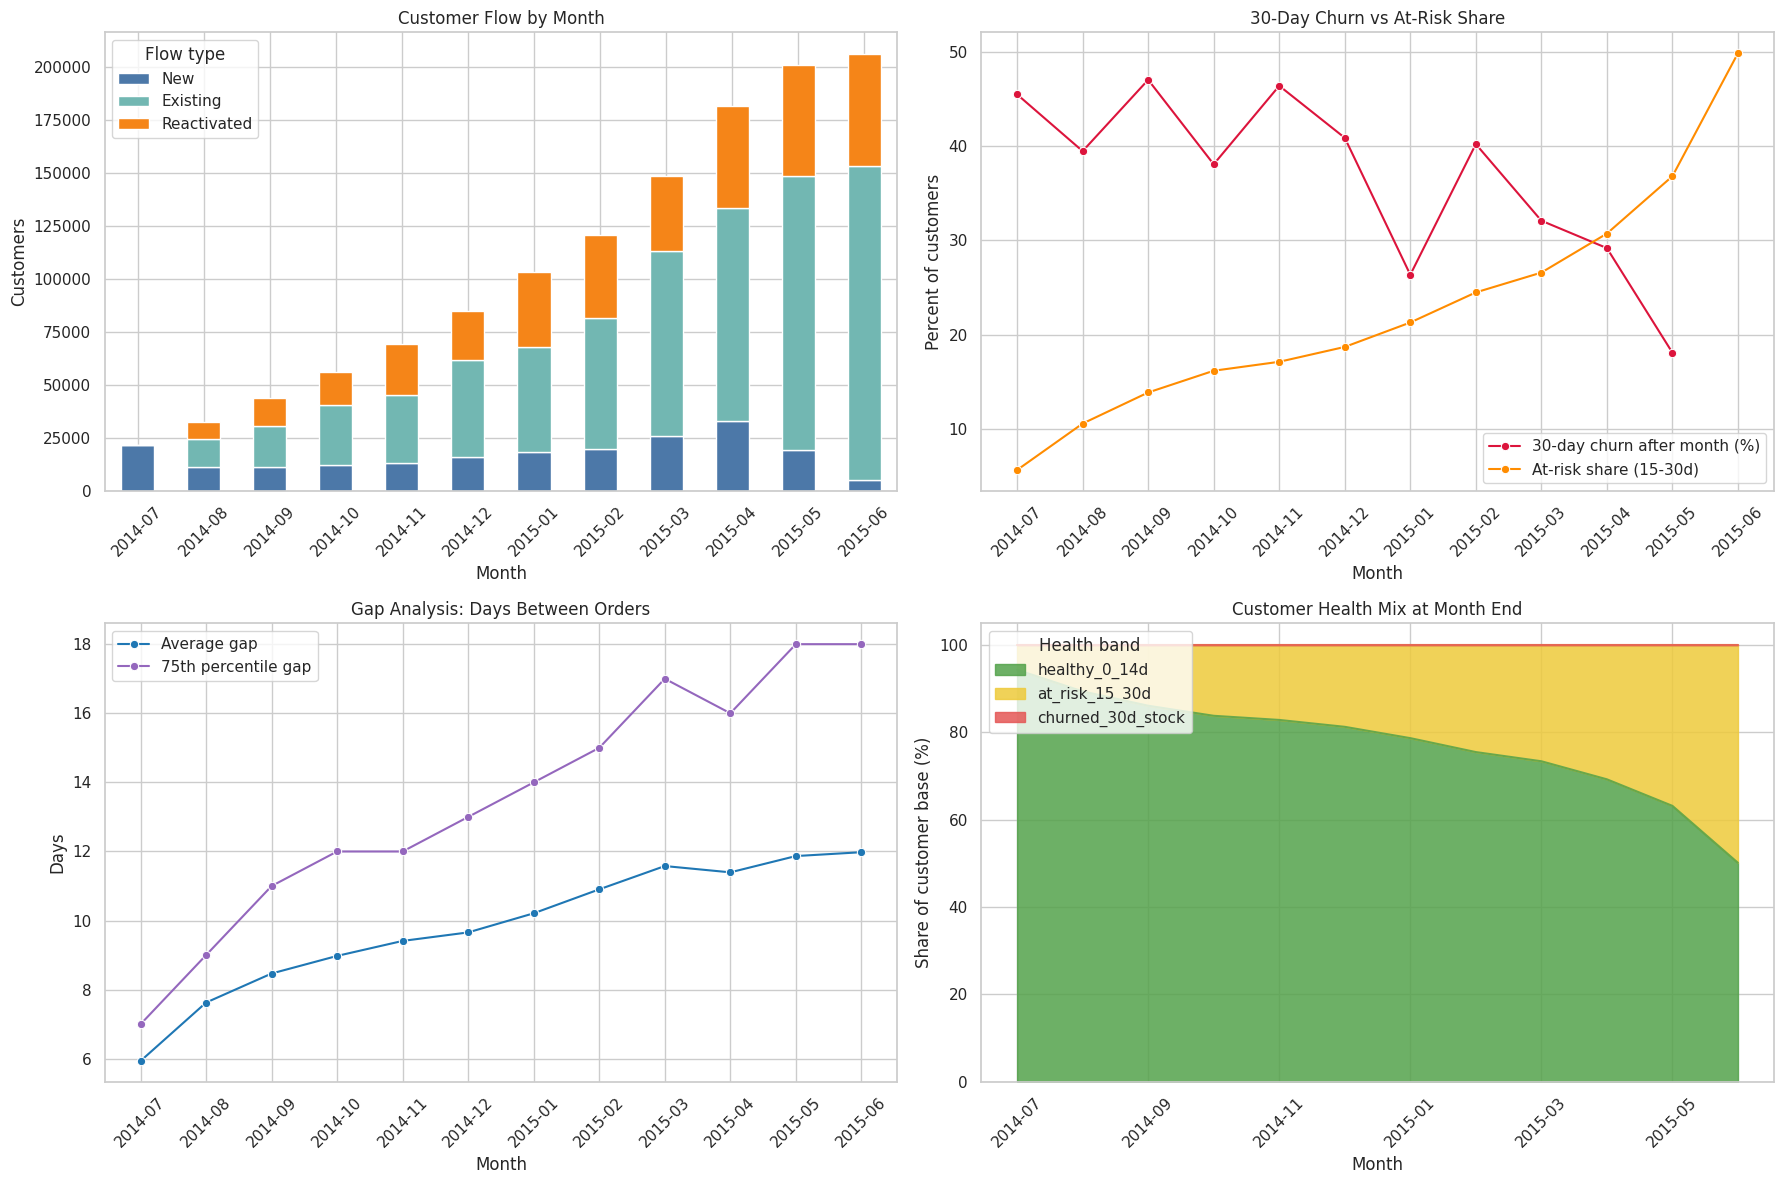

/tmp/ipykernel_12121/386701583.py:351: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


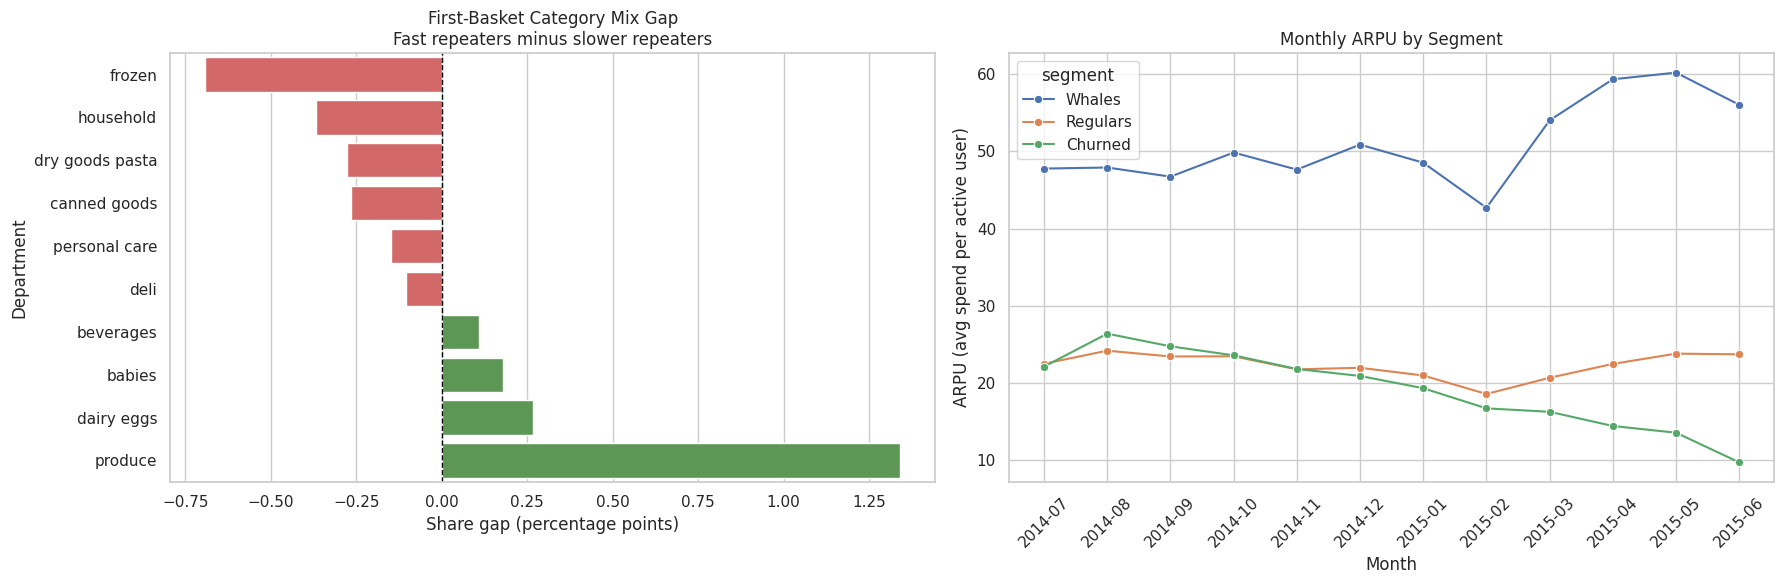

Customer flow + 30-day churn snapshot:


,order_month,New,Existing,Reactivated,active_customers,churn_30d_rate_pct,at_risk_share_pct
0,2014-07-01,21549.0,0.0,0.0,21549.0,45.477748,5.647594
1,2014-08-01,11037.0,13567.0,7982.0,32586.0,39.461732,10.572025
2,2014-09-01,11102.0,19420.0,13166.0,43688.0,47.026643,13.866508
3,2014-10-01,12296.0,28268.0,15420.0,55984.0,38.068019,16.172478
4,2014-11-01,13266.0,32073.0,23911.0,69250.0,46.391336,17.122022
5,2014-12-01,15788.0,46091.0,23159.0,85038.0,40.874668,18.698699
6,2015-01-01,18212.0,49586.0,35452.0,103250.0,26.352542,21.290073
7,2015-02-01,19558.0,62200.0,39085.0,120843.0,40.208370,24.480490
8,2015-03-01,25929.0,87520.0,35288.0,148737.0,32.086166,26.583164
9,2015-04-01,33115.0,100673.0,48064.0,181852.0,29.179223,30.720036


Gap analysis snapshot:


,order_month,avg_gap_days,median_gap_days,p75_gap_days,long_gap_orders_pct
0,2014-07-01,5.935956,6.0,7.0,0.0
1,2014-08-01,7.626864,6.0,9.0,0.0
2,2014-09-01,8.467878,7.0,11.0,0.0
3,2014-10-01,8.977261,7.0,12.0,0.0
4,2014-11-01,9.411242,7.0,12.0,0.0
5,2014-12-01,9.657633,7.0,13.0,0.0
6,2015-01-01,10.211099,7.0,14.0,0.0
7,2015-02-01,10.903993,7.0,15.0,0.0
8,2015-03-01,11.578351,8.0,17.0,0.0
9,2015-04-01,11.395823,8.0,16.0,0.0


First-basket profile by repeat-speed proxy:


...

First-basket department mix gaps (fast minus slow repeaters):


journey_type,department,fast_minus_slow_pct_pt
10,frozen,-0.692410
11,household,-0.368748
9,dry goods pasta,-0.276675
6,canned goods,-0.266144
17,personal care,-0.149544
8,deli,-0.103946
3,beverages,0.107454
1,babies,0.179185
7,dairy eggs,0.268115
19,produce,1.341606


Monthly ARPU by segment:


,order_month,segment,active_customers,total_monthly_spend,arpu
24,2015-03-01,Whales,19991,1079509,53.999750
25,2015-03-01,Regulars,83143,1719896,20.685999
26,2015-03-01,Churned,45603,742592,16.283841
27,2015-04-01,Whales,20013,1187047,59.313796
28,2015-04-01,Regulars,101841,2289614,22.482242
29,2015-04-01,Churned,59998,866820,14.447482
30,2015-05-01,Whales,20021,1204765,60.175066
31,2015-05-01,Regulars,117853,2806462,23.813242
32,2015-05-01,Churned,63181,857900,13.578449
33,2015-06-01,Whales,20024,1121555,56.010537


Churn & customer health summary
- May 2015: 30-day churn after month = 18.1% (36,362 of 201,055 active customers).
- Jun 2015: at-risk share (15-30 days since last order) = 49.9% of the active customer base.
- Latest order gap: avg = 12.0 days, p75 = 18.0 days.
- Fast repeaters over-index in 'produce', while slower repeaters over-index in 'frozen'.
- Latest ARPU by segment:
  • Whales: 56.0 spend per active user in Jun 2015
  • Regulars: 23.7 spend per active user in Jun 2015
  • Churned: 9.7 spend per active user in Jun 2015


In [4]:
# --- Retention, churn (30-day rule), and customer health diagnostics ---
CHURN_DAYS = 30
AT_RISK_START = 15
FAST_REPEAT_DAYS = 7

analysis_months = trend_monthly["order_month"].drop_duplicates().sort_values()
month_calendar = pd.DataFrame({"order_month": pd.Index(analysis_months)})
month_calendar["month_label"] = month_calendar["order_month"].dt.strftime("%Y-%m")
month_calendar["month_end"] = month_calendar["order_month"] + pd.offsets.MonthEnd(1)

# 1) Customer flow: new vs existing vs reactivated, plus 30-day churn after each month.
customer_month_activity = (
    order_value.groupby(["user_id", "order_month"], observed=False)
    .agg(
        first_order_in_month=("order_date", "min"),
        last_order_in_month=("order_date", "max"),
    )
    .reset_index()
    .sort_values(["user_id", "order_month"])
)
customer_month_activity["first_order_month"] = customer_month_activity.groupby(
    "user_id", observed=False
)["order_month"].transform("min")
customer_month_activity["prev_order_date"] = customer_month_activity.groupby(
    "user_id", observed=False
)["first_order_in_month"].shift()
customer_month_activity["gap_from_prev_order"] = (
    customer_month_activity["first_order_in_month"] - customer_month_activity["prev_order_date"]
).dt.days
customer_month_activity["next_order_date"] = customer_month_activity.groupby(
    "user_id", observed=False
)["last_order_in_month"].shift(-1)
customer_month_activity["days_to_next_order"] = (
    customer_month_activity["next_order_date"] - customer_month_activity["last_order_in_month"]
).dt.days
customer_month_activity["customer_flow"] = np.select(
    [
        customer_month_activity["order_month"].eq(customer_month_activity["first_order_month"]),
        customer_month_activity["gap_from_prev_order"].gt(CHURN_DAYS),
    ],
    ["New", "Reactivated"],
    default="Existing",
)
customer_month_activity["customer_flow"] = pd.Categorical(
    customer_month_activity["customer_flow"],
    categories=["New", "Existing", "Reactivated"],
    ordered=True,
)
customer_month_activity = customer_month_activity.merge(
    month_calendar[["order_month", "month_end", "month_label"]],
    on="order_month",
    how="inner",
)
customer_month_activity["lookahead_complete"] = (
    customer_month_activity["month_end"] + pd.Timedelta(days=CHURN_DAYS) <= latest_order_date
)
customer_month_activity["churned_30d_after_month"] = np.where(
    customer_month_activity["lookahead_complete"],
    (
        customer_month_activity["days_to_next_order"].isna()
        | customer_month_activity["days_to_next_order"].gt(CHURN_DAYS)
    ).astype(float),
    np.nan,
)

flow_summary = (
    customer_month_activity.groupby(["order_month", "month_label", "customer_flow"], observed=False)
    .agg(customers=("user_id", "nunique"))
    .reset_index()
)
customer_flow_summary = (
    flow_summary.pivot_table(
        index=["order_month", "month_label"],
        columns="customer_flow",
        values="customers",
        fill_value=0,
    )
    .reset_index()
)
for col in ["New", "Existing", "Reactivated"]:
    if col not in customer_flow_summary.columns:
        customer_flow_summary[col] = 0
customer_flow_summary["active_customers"] = customer_flow_summary[["New", "Existing", "Reactivated"]].sum(axis=1)

churn_after_summary = (
    customer_month_activity.groupby(["order_month", "month_label"], observed=False)
    .agg(
        observed_customers=("churned_30d_after_month", lambda s: s.notna().sum()),
        churned_30d_after_month=("churned_30d_after_month", "sum"),
    )
    .reset_index()
)
churn_after_summary["churn_30d_rate_pct"] = (
    100
    * churn_after_summary["churned_30d_after_month"]
    / churn_after_summary["observed_customers"].replace(0, np.nan)
)

# 2) Customer health at month end: healthy vs at-risk vs already past 30 days.
all_users = order_value[["user_id"]].drop_duplicates()
user_month_grid = (
    all_users.assign(key=1)
    .merge(month_calendar.assign(key=1), on="key")
    .drop(columns="key")
    .sort_values(["month_end", "user_id"])
    .reset_index(drop=True)
)
user_order_history = (
    order_value[["user_id", "order_date"]]
    .drop_duplicates()
    .sort_values(["order_date", "user_id"])
    .reset_index(drop=True)
)
customer_health_state = pd.merge_asof(
    user_month_grid,
    user_order_history,
    by="user_id",
    left_on="month_end",
    right_on="order_date",
    direction="backward",
)
customer_health_state = customer_health_state.rename(
    columns={"order_date": "last_order_date_to_month_end"}
)
customer_health_state["days_since_last_order"] = (
    customer_health_state["month_end"] - customer_health_state["last_order_date_to_month_end"]
).dt.days

monthly_health = (
    customer_health_state.groupby(["order_month", "month_label"], observed=False)
    .agg(
        customer_base=("last_order_date_to_month_end", lambda s: s.notna().sum()),
        healthy_0_14d=(
            "days_since_last_order",
            lambda s: s.between(0, AT_RISK_START - 1, inclusive="both").sum(),
        ),
        at_risk_15_30d=(
            "days_since_last_order",
            lambda s: s.between(AT_RISK_START, CHURN_DAYS, inclusive="both").sum(),
        ),
        churned_30d_stock=("days_since_last_order", lambda s: s.gt(CHURN_DAYS).sum()),
    )
    .reset_index()
    .sort_values("order_month")
)
monthly_health["at_risk_share_pct"] = (
    100 * monthly_health["at_risk_15_30d"] / monthly_health["customer_base"]
)
monthly_health["churned_stock_share_pct"] = (
    100 * monthly_health["churned_30d_stock"] / monthly_health["customer_base"]
)

customer_flow_health = (
    customer_flow_summary.merge(churn_after_summary, on=["order_month", "month_label"], how="left")
    .merge(monthly_health, on=["order_month", "month_label"], how="left")
    .sort_values("order_month")
)

# 3) Gap analysis: average days between orders and long-gap warning share.
order_gap = order_value.sort_values(["user_id", "order_date", "order_id"]).copy()
order_gap["prev_order_date"] = order_gap.groupby("user_id", observed=False)["order_date"].shift()
order_gap["gap_days"] = (order_gap["order_date"] - order_gap["prev_order_date"]).dt.days
if exclude_partial_month:
    order_gap = order_gap[order_gap["order_month"] < latest_month].copy()

gap_diagnostics = (
    order_gap.dropna(subset=["gap_days"])
    .groupby("order_month", observed=False)
    .agg(
        avg_gap_days=("gap_days", "mean"),
        median_gap_days=("gap_days", "median"),
        p75_gap_days=("gap_days", lambda s: s.quantile(0.75)),
        long_gap_orders_pct=("gap_days", lambda s: 100 * s.gt(CHURN_DAYS).mean()),
    )
    .reset_index()
    .sort_values("order_month")
)
gap_diagnostics["month_label"] = gap_diagnostics["order_month"].dt.strftime("%Y-%m")

# 4) First-basket diagnostics: fast repeaters vs slower repeaters as a proxy for early churn risk.
first_repeat_orders = order_value.sort_values(["user_id", "order_date", "order_id"]).copy()
first_repeat_orders["order_number_rank"] = first_repeat_orders.groupby("user_id", observed=False).cumcount() + 1
first_second_orders = (
    first_repeat_orders[first_repeat_orders["order_number_rank"].isin([1, 2])]
    .pivot(index="user_id", columns="order_number_rank", values=["order_id", "order_date"])
)
first_second_orders.columns = [
    "first_order_id",
    "second_order_id",
    "first_order_date",
    "second_order_date",
]
first_second_orders = first_second_orders.reset_index()
first_second_orders["days_to_second_order"] = (
    first_second_orders["second_order_date"] - first_second_orders["first_order_date"]
).dt.days
first_second_orders["journey_type"] = np.where(
    first_second_orders["days_to_second_order"].le(FAST_REPEAT_DAYS),
    f"Fast repeat (<={FAST_REPEAT_DAYS}d)",
    f"Slow repeat ({FAST_REPEAT_DAYS + 1}d+)",
)

first_order_items = df.merge(
    first_second_orders[["user_id", "first_order_id", "journey_type"]],
    left_on=["user_id", "order_id"],
    right_on=["user_id", "first_order_id"],
    how="inner",
)
first_order_baskets = (
    first_order_items.groupby(["journey_type", "user_id", "order_id"], observed=False)
    .agg(
        first_basket_items=("product_id", "count"),
        unique_departments=("department", "nunique"),
        unique_aisles=("aisle", "nunique"),
    )
    .reset_index()
)
first_order_profile = (
    first_order_baskets.groupby("journey_type", observed=False)
    .agg(
        customers=("user_id", "nunique"),
        avg_first_basket_items=("first_basket_items", "mean"),
        median_first_basket_items=("first_basket_items", "median"),
        avg_unique_departments=("unique_departments", "mean"),
        avg_unique_aisles=("unique_aisles", "mean"),
    )
    .reset_index()
    .sort_values("customers", ascending=False)
)

department_mix = (
    first_order_items.groupby(["journey_type", "department"], observed=False)
    .size()
    .rename("item_count")
    .reset_index()
)
department_mix["share_pct"] = (
    100
    * department_mix["item_count"]
    / department_mix.groupby("journey_type", observed=False)["item_count"].transform("sum")
)
department_compare = (
    department_mix.pivot(index="department", columns="journey_type", values="share_pct")
    .fillna(0)
    .reset_index()
)
fast_col = f"Fast repeat (<={FAST_REPEAT_DAYS}d)"
slow_col = f"Slow repeat ({FAST_REPEAT_DAYS + 1}d+)"
department_compare["fast_minus_slow_pct_pt"] = (
    department_compare.get(fast_col, 0) - department_compare.get(slow_col, 0)
)
department_gap = (
    department_compare.reindex(
        department_compare["fast_minus_slow_pct_pt"].abs().sort_values(ascending=False).index
    )
    .head(10)
    .sort_values("fast_minus_slow_pct_pt")
)

# 5) Monthly ARPU by segment so cumulative CLV does not hide softening spend.
segment_health_trend = segment_clv_trend.copy()
segment_health_trend["arpu"] = (
    segment_health_trend["total_monthly_spend"] / segment_health_trend["active_customers"]
)
segment_health_trend = segment_health_trend.sort_values(["order_month", "segment"])

# --- Visual summary ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

customer_flow_summary.set_index("month_label")[["New", "Existing", "Reactivated"]].plot(
    kind="bar",
    stacked=True,
    ax=axes[0, 0],
    color=["#4C78A8", "#72B7B2", "#F58518"],
)
axes[0, 0].set_title("Customer Flow by Month")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Customers")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].legend(title="Flow type")

sns.lineplot(
    data=customer_flow_health,
    x="month_label",
    y="churn_30d_rate_pct",
    marker="o",
    ax=axes[0, 1],
    color="crimson",
    label="30-day churn after month (%)",
)
sns.lineplot(
    data=customer_flow_health,
    x="month_label",
    y="at_risk_share_pct",
    marker="o",
    ax=axes[0, 1],
    color="darkorange",
    label="At-risk share (15-30d)",
)
axes[0, 1].set_title("30-Day Churn vs At-Risk Share")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Percent of customers")
axes[0, 1].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=gap_diagnostics,
    x="month_label",
    y="avg_gap_days",
    marker="o",
    ax=axes[1, 0],
    color="tab:blue",
    label="Average gap",
)
sns.lineplot(
    data=gap_diagnostics,
    x="month_label",
    y="p75_gap_days",
    marker="o",
    ax=axes[1, 0],
    color="tab:purple",
    label="75th percentile gap",
)
axes[1, 0].set_title("Gap Analysis: Days Between Orders")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Days")
axes[1, 0].tick_params(axis="x", rotation=45)

health_mix_pct = (
    monthly_health.set_index("month_label")[["healthy_0_14d", "at_risk_15_30d", "churned_30d_stock"]]
    .div(monthly_health.set_index("month_label")["customer_base"], axis=0)
    .mul(100)
)
health_mix_pct.plot(
    kind="area",
    stacked=True,
    ax=axes[1, 1],
    color=["#54A24B", "#EECA3B", "#E45756"],
    alpha=0.85,
)
axes[1, 1].set_title("Customer Health Mix at Month End")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Share of customer base (%)")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].legend(title="Health band", loc="upper left")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=department_gap,
    y="department",
    x="fast_minus_slow_pct_pt",
    ax=axes[0],
    palette=["#E45756" if v < 0 else "#54A24B" for v in department_gap["fast_minus_slow_pct_pt"]],
)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("First-Basket Category Mix Gap\nFast repeaters minus slower repeaters")
axes[0].set_xlabel("Share gap (percentage points)")
axes[0].set_ylabel("Department")

sns.lineplot(
    data=segment_health_trend,
    x="month_label",
    y="arpu",
    hue="segment",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Monthly ARPU by Segment")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("ARPU (avg spend per active user)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# --- Tables + business-friendly takeaways ---
show_df(
    customer_flow_health[[
        "order_month",
        "New",
        "Existing",
        "Reactivated",
        "active_customers",
        "churn_30d_rate_pct",
        "at_risk_share_pct",
    ]],
    title="Customer flow + 30-day churn snapshot:",
)
show_df(
    gap_diagnostics[[
        "order_month",
        "avg_gap_days",
        "median_gap_days",
        "p75_gap_days",
        "long_gap_orders_pct",
    ]],
    title="Gap analysis snapshot:",
)
show_df(first_order_profile, title="First-basket profile by repeat-speed proxy:")
show_df(
    department_gap[["department", "fast_minus_slow_pct_pt"]],
    title="First-basket department mix gaps (fast minus slow repeaters):",
)
show_df(
    segment_health_trend[["order_month", "segment", "active_customers", "total_monthly_spend", "arpu"]].tail(12),
    title="Monthly ARPU by segment:",
)

latest_churn_row = customer_flow_health.dropna(subset=["churn_30d_rate_pct"]).iloc[-1]
latest_health_row = monthly_health.iloc[-1]
latest_gap_row = gap_diagnostics.iloc[-1]
latest_arpu_month = segment_health_trend["order_month"].max()
latest_arpu = segment_health_trend[segment_health_trend["order_month"] == latest_arpu_month].copy()
fast_leader = department_gap.loc[department_gap["fast_minus_slow_pct_pt"].idxmax(), "department"]
slow_leader = department_gap.loc[department_gap["fast_minus_slow_pct_pt"].idxmin(), "department"]

print("Churn & customer health summary")
print(
    f"- {latest_churn_row['order_month']:%b %Y}: 30-day churn after month = "
    f"{latest_churn_row['churn_30d_rate_pct']:.1f}% "
    f"({int(latest_churn_row['churned_30d_after_month']):,} of {int(latest_churn_row['observed_customers']):,} active customers)."
)
print(
    f"- {latest_health_row['order_month']:%b %Y}: at-risk share (15-30 days since last order) = "
    f"{latest_health_row['at_risk_share_pct']:.1f}% of the active customer base."
)
print(
    f"- Latest order gap: avg = {latest_gap_row['avg_gap_days']:.1f} days, "
    f"p75 = {latest_gap_row['p75_gap_days']:.1f} days."
)
print(
    f"- Fast repeaters over-index in '{fast_leader}', while slower repeaters over-index in '{slow_leader}'."
)
print("- Latest ARPU by segment:")
for row in latest_arpu.sort_values("arpu", ascending=False).itertuples():
    print(f"  • {row.segment}: {row.arpu:.1f} spend per active user in {row.order_month:%b %Y}")

### Business takeaways from this churn view

- **Active growth ไม่ได้แปลว่า health ดีขึ้นเสมอ**: แม้ active customers โตต่อ แต่ `30-day churn after month` ยังอยู่ระดับสูงหลายเดือน
- **สัญญาณเตือนล่าสุดชัดมาก**: ใน `Jun 2015` กลุ่ม `at-risk (15-30 days)` ขึ้นถึงประมาณ **49.9%** ของฐานลูกค้า
- **Gap กำลังกว้างขึ้น**: average gap ขยับจากราว **5.9 วัน** ใน `Jul 2014` เป็นประมาณ **12.0 วัน** ใน `Jun 2015`
- **ARPU ช่วยจับ softening spend**: กลุ่ม `Churned` มี ARPU ลดลงเหลือประมาณ **9.7** ใน `Jun 2015` ขณะที่ `Whales` ยังสูงราว **56.0**
- **พฤติกรรมตะกร้าแรกต่างกัน**: fast repeaters over-index ใน `produce` และ `dairy eggs` มากกว่า ส่วน slower repeaters จะหนักไปทาง `frozen` และ `household`

### How to read this section

- ถ้า `Active Customers` โต แต่ `30-day churn after month (%)` ยังสูง แปลว่า growth อาจมาจากลูกค้าใหม่มาถม ไม่ใช่ retention ที่ดีขึ้น
- ถ้า `at-risk share (15-30d)` หรือ `p75 gap days` สูงขึ้นต่อเนื่อง ให้ถือเป็น early warning ก่อน churn
- ใช้ `ARPU by segment` ควบคู่ `Cumulative CLV` เสมอ เพื่อดูว่าลูกค้าแต่ละกลุ่มเริ่มจ่ายน้อยลงหรือไม่

### 8) Customer Health Score Dashboard

สรุปสถานะลูกค้าปัจจุบันเป็น 3 ระดับ: `Healthy`, `Watchlist`, `Critical`

**Scoring logic (heuristic):**
- `Recency` = ความสดใหม่ของการซื้อครั้งล่าสุด
- `Frequency` = จำนวนออเดอร์สะสม
- `Loyalty` = สัดส่วนการซื้อซ้ำ (`reorder_ratio`)
- `Basket strength` = ขนาดตะกร้าเฉลี่ย

> สูตรนี้เป็น dashboard เชิงธุรกิจสำหรับ early warning และสามารถปรับน้ำหนักให้เหมาะกับโจทย์ retention จริงได้

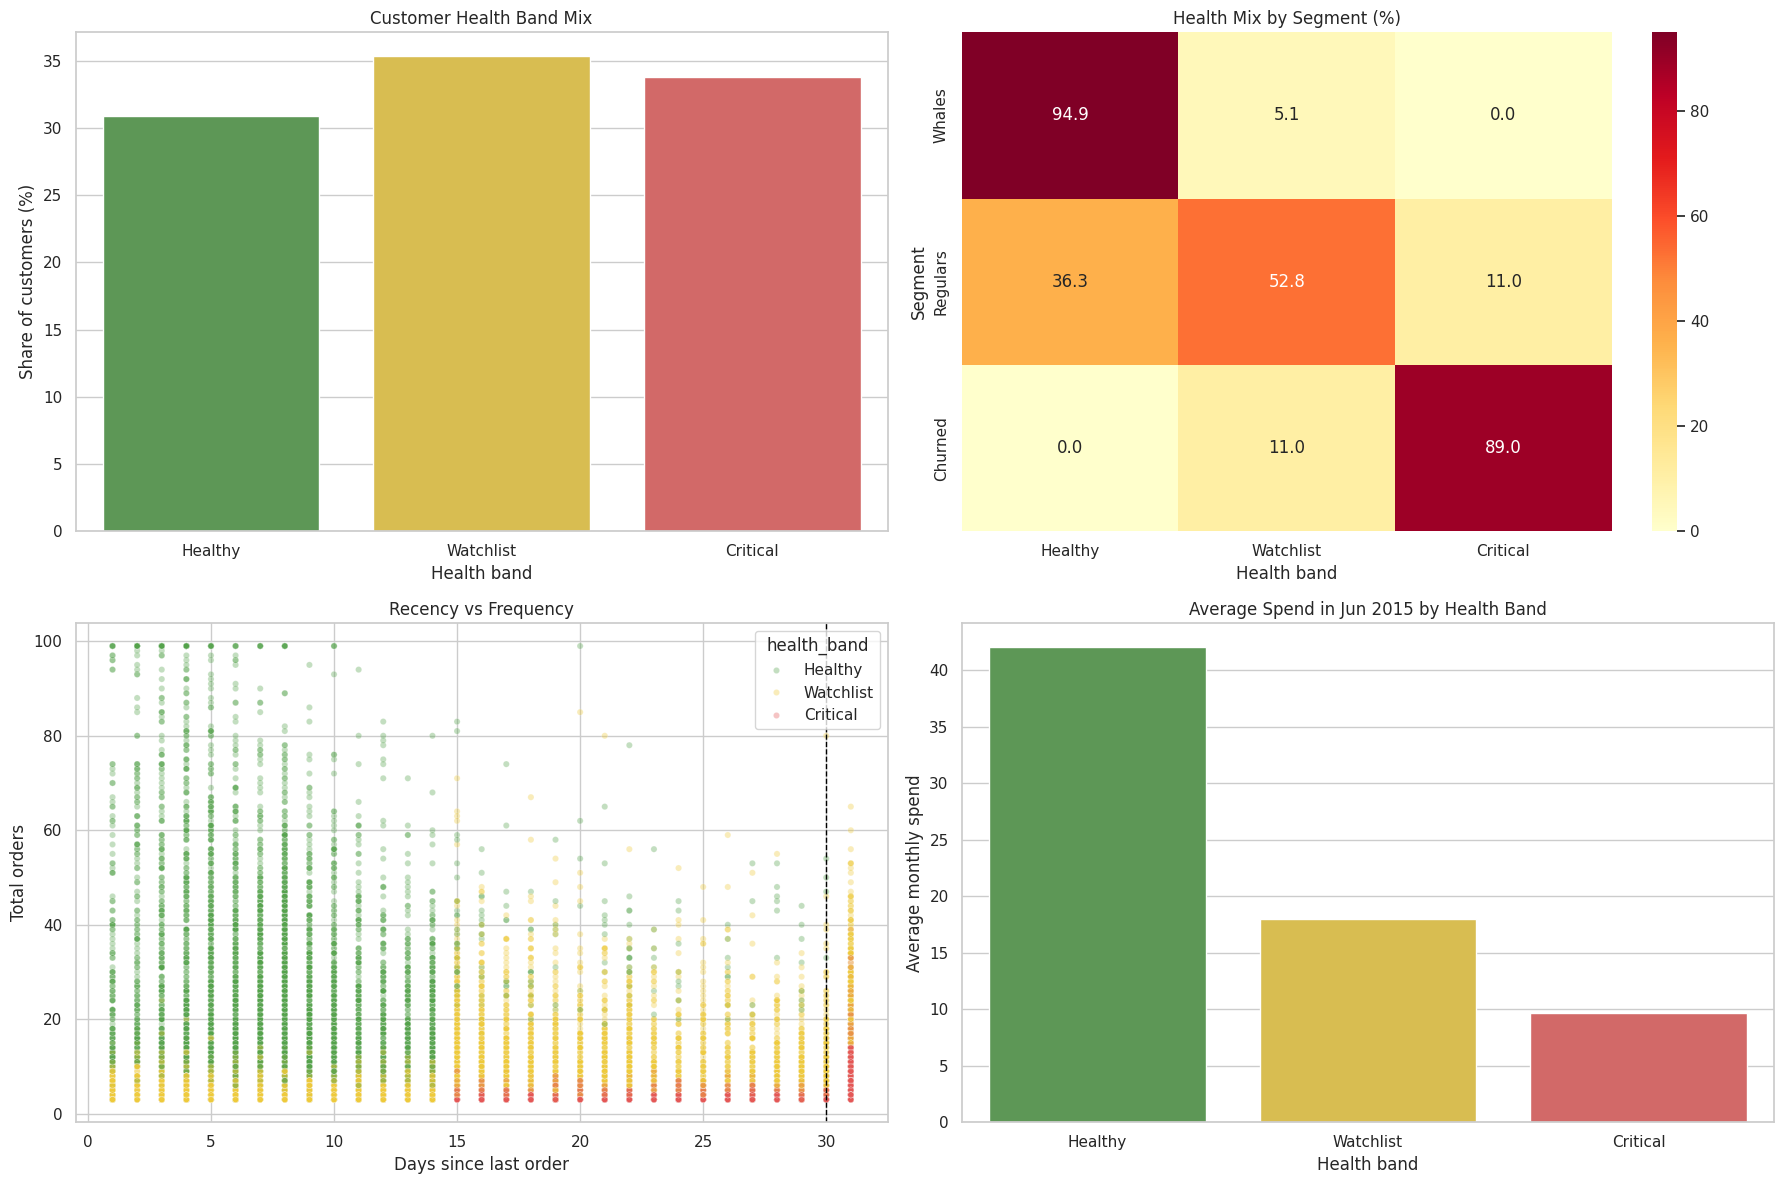

Customer health score summary:


,health_band,customers,customer_share_pct,avg_health_score,avg_days_since_last_order,avg_total_orders,avg_reorder_ratio_pct,avg_latest_month_spend
0,Healthy,63622,30.853164,81.646305,7.803166,30.548159,60.799305,42.029172
1,Watchlist,72864,35.335024,57.919038,16.384236,11.405674,40.706822,17.957565
2,Critical,69723,33.811812,31.848169,29.175853,6.314645,29.819912,9.636562


High-risk customers snapshot (Critical + Watchlist):


,user_id,segment,health_band,health_score,days_since_last_order,total_orders,reorder_ratio,latest_month_spend
7620,7621,Churned,Critical,12.7,31,3,0.0,1.0
7856,7857,Churned,Critical,12.7,31,3,0.0,1.0
10014,10015,Churned,Critical,12.7,31,3,0.0,1.0
10406,10407,Churned,Critical,12.7,31,3,0.0,1.0
19494,19495,Churned,Critical,12.7,31,3,0.0,1.0
22225,22226,Churned,Critical,12.7,31,3,0.0,1.0
38161,38162,Churned,Critical,12.7,31,3,0.0,1.0
40762,40763,Churned,Critical,12.7,31,3,0.0,1.0
42673,42674,Churned,Critical,12.7,31,3,0.0,1.0
43647,43648,Churned,Critical,12.7,31,3,0.0,1.0


Customer health score summary
- Healthy = 30.9% | Watchlist = 35.3% | Critical = 33.8% of customers.
- Highest critical concentration is in 'Churned' (89.0% critical).
- Critical customers average 29.2 days since last order and only 9.6 spend in Jun 2015.
- Healthy customers average score = 81.6, versus 57.9 for Watchlist.


: 

In [ ]:
# --- Customer health score dashboard ---
HEALTHY_THRESHOLD = 70
WATCHLIST_THRESHOLD = 45
HEALTH_PALETTE = {
    "Healthy": "#54A24B",
    "Watchlist": "#EECA3B",
    "Critical": "#E45756",
}
health_band_order = ["Healthy", "Watchlist", "Critical"]

customer_health_dashboard = rfm.copy()
customer_health_dashboard["frequency_score"] = (
    customer_health_dashboard["total_orders"].rank(pct=True) * 100
)
customer_health_dashboard["basket_score"] = (
    customer_health_dashboard["avg_basket_size"].rank(pct=True) * 100
)
customer_health_dashboard["loyalty_score"] = (
    customer_health_dashboard["reorder_ratio"].fillna(0).clip(0, 1) * 100
)
customer_health_dashboard["recency_score"] = np.select(
    [
        customer_health_dashboard["days_since_last_order"].le(14),
        customer_health_dashboard["days_since_last_order"].between(15, 30, inclusive="both"),
        customer_health_dashboard["days_since_last_order"].between(31, 45, inclusive="both"),
    ],
    [100, 60, 25],
    default=5,
)
customer_health_dashboard["health_score"] = (
    0.45 * customer_health_dashboard["recency_score"]
    + 0.25 * customer_health_dashboard["frequency_score"]
    + 0.20 * customer_health_dashboard["loyalty_score"]
    + 0.10 * customer_health_dashboard["basket_score"]
).round(1)
customer_health_dashboard["health_band"] = pd.cut(
    customer_health_dashboard["health_score"],
    bins=[-np.inf, WATCHLIST_THRESHOLD, HEALTHY_THRESHOLD, np.inf],
    labels=["Critical", "Watchlist", "Healthy"],
    right=False,
)
customer_health_dashboard["health_band"] = pd.Categorical(
    customer_health_dashboard["health_band"],
    categories=health_band_order,
    ordered=True,
)

latest_health_month = trend_monthly["order_month"].max()
latest_month_spend = (
    customer_monthly[customer_monthly["order_month"] == latest_health_month][
        ["user_id", "monthly_spend", "cumulative_clv"]
    ]
    .rename(
        columns={
            "monthly_spend": "latest_month_spend",
            "cumulative_clv": "latest_cumulative_clv",
        }
    )
)
customer_health_dashboard = customer_health_dashboard.merge(
    latest_month_spend,
    on="user_id",
    how="left",
)
customer_health_dashboard[["latest_month_spend", "latest_cumulative_clv"]] = (
    customer_health_dashboard[["latest_month_spend", "latest_cumulative_clv"]].fillna(0)
)

health_band_summary = (
    customer_health_dashboard.groupby("health_band", observed=False)
    .agg(
        customers=("user_id", "nunique"),
        avg_health_score=("health_score", "mean"),
        avg_days_since_last_order=("days_since_last_order", "mean"),
        avg_total_orders=("total_orders", "mean"),
        avg_reorder_ratio=("reorder_ratio", "mean"),
        avg_latest_month_spend=("latest_month_spend", "mean"),
    )
    .reindex(health_band_order)
    .reset_index()
)
health_band_summary["customer_share_pct"] = (
    100 * health_band_summary["customers"] / health_band_summary["customers"].sum()
)
health_band_summary["avg_reorder_ratio_pct"] = (
    100 * health_band_summary["avg_reorder_ratio"]
)

segment_health_mix = (
    pd.crosstab(
        customer_health_dashboard["segment"],
        customer_health_dashboard["health_band"],
        normalize="index",
    )
    * 100
)
segment_health_mix = segment_health_mix.reindex(index=segment_order, columns=health_band_order).fillna(0)

band_spend_summary = (
    customer_health_dashboard.groupby("health_band", observed=False)
    .agg(
        avg_latest_month_spend=("latest_month_spend", "mean"),
        median_latest_month_spend=("latest_month_spend", "median"),
    )
    .reindex(health_band_order)
    .reset_index()
)

risk_watchlist = (
    customer_health_dashboard[
        customer_health_dashboard["health_band"].isin(["Critical", "Watchlist"])
    ]
    .sort_values(["health_score", "days_since_last_order"], ascending=[True, False])
    [[
        "user_id",
        "segment",
        "health_band",
        "health_score",
        "days_since_last_order",
        "total_orders",
        "reorder_ratio",
        "latest_month_spend",
    ]]
)
risk_watchlist["reorder_ratio"] = risk_watchlist["reorder_ratio"] * 100

plot_sample = customer_health_dashboard.sample(
    min(15000, len(customer_health_dashboard)),
    random_state=42,
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(
    data=health_band_summary,
    x="health_band",
    y="customer_share_pct",
    hue="health_band",
    palette=HEALTH_PALETTE,
    dodge=False,
    ax=axes[0, 0],
)
if axes[0, 0].legend_ is not None:
    axes[0, 0].legend_.remove()
axes[0, 0].set_title("Customer Health Band Mix")
axes[0, 0].set_xlabel("Health band")
axes[0, 0].set_ylabel("Share of customers (%)")

sns.heatmap(segment_health_mix, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[0, 1])
axes[0, 1].set_title("Health Mix by Segment (%)")
axes[0, 1].set_xlabel("Health band")
axes[0, 1].set_ylabel("Segment")

sns.scatterplot(
    data=plot_sample,
    x="days_since_last_order",
    y="total_orders",
    hue="health_band",
    hue_order=health_band_order,
    palette=HEALTH_PALETTE,
    alpha=0.35,
    s=20,
    ax=axes[1, 0],
)
axes[1, 0].axvline(CHURN_DAYS, color="black", linestyle="--", linewidth=1)
axes[1, 0].set_title("Recency vs Frequency")
axes[1, 0].set_xlabel("Days since last order")
axes[1, 0].set_ylabel("Total orders")

sns.barplot(
    data=band_spend_summary,
    x="health_band",
    y="avg_latest_month_spend",
    hue="health_band",
    palette=HEALTH_PALETTE,
    dodge=False,
    ax=axes[1, 1],
)
if axes[1, 1].legend_ is not None:
    axes[1, 1].legend_.remove()
axes[1, 1].set_title(f"Average Spend in {latest_health_month:%b %Y} by Health Band")
axes[1, 1].set_xlabel("Health band")
axes[1, 1].set_ylabel("Average monthly spend")

plt.tight_layout()
plt.show()

show_df(
    health_band_summary[[
        "health_band",
        "customers",
        "customer_share_pct",
        "avg_health_score",
        "avg_days_since_last_order",
        "avg_total_orders",
        "avg_reorder_ratio_pct",
        "avg_latest_month_spend",
    ]],
    title="Customer health score summary:",
)
show_df(
    risk_watchlist.head(15),
    title="High-risk customers snapshot (Critical + Watchlist):",
)

healthy_row = health_band_summary[health_band_summary["health_band"] == "Healthy"].iloc[0]
watchlist_row = health_band_summary[health_band_summary["health_band"] == "Watchlist"].iloc[0]
critical_row = health_band_summary[health_band_summary["health_band"] == "Critical"].iloc[0]
riskiest_segment = segment_health_mix["Critical"].idxmax()

print("Customer health score summary")
print(
    f"- Healthy = {healthy_row['customer_share_pct']:.1f}% | "
    f"Watchlist = {watchlist_row['customer_share_pct']:.1f}% | "
    f"Critical = {critical_row['customer_share_pct']:.1f}% of customers."
)
print(
    f"- Highest critical concentration is in '{riskiest_segment}' "
    f"({segment_health_mix.loc[riskiest_segment, 'Critical']:.1f}% critical)."
)
print(
    f"- Critical customers average {critical_row['avg_days_since_last_order']:.1f} days since last order "
    f"and only {critical_row['avg_latest_month_spend']:.1f} spend in {latest_health_month:%b %Y}."
)
print(
    f"- Healthy customers average score = {healthy_row['avg_health_score']:.1f}, "
    f"versus {watchlist_row['avg_health_score']:.1f} for Watchlist."
)

## สมมติฐาน
สมมติฐาน: ถ้า Correlation ในช่วง 1-15 วันยังเป็นบวกอ่อนๆ แต่พอหลัง 15 วัน Correlation พลิกเป็นลบอย่างรุนแรง (Negative Correlation) นั่นแปลว่า 15 วันคือ "Magic Number" ที่คุณต้องรักษาลูกค้าไว้ให้ได้

### 9) Recency Threshold Diagnostics: Correlation, Conditional Probability, and Retention Curves

ส่วนนี้ตอบ 3 คำถามเพิ่ม:
1. **Correlation rolling windows** — ความสัมพันธ์ระหว่าง `days_since_last_order` กับโอกาสซื้อในอนาคตเปลี่ยนอย่างไรตามช่วงวัน
2. **Conditional probability** — เปรียบเทียบ `P(Buy again | Recency <= 15)` กับ `P(Buy again | Recency > 15)`
3. **Retention curve by cohort** — โค้งอัตราการกลับมาซื้อแยกตามกลุ่ม recency ล่าสุด

> หมายเหตุสำคัญ: ในข้อมูล Instacart ตัวแปรช่วงห่างระหว่างออเดอร์มีเพดานที่ `30 วัน`  
> ดังนั้น `buy again within 30 days` จะค่อนข้าง trivial สำหรับลูกค้าที่เพิ่งซื้อในรอบล่าสุด  
> เพื่อให้เห็นสัญญาณเชิงปฏิบัติจริง ส่วนนี้จึงใช้ **next 7-day / 14-day purchase propensity** เป็น early-warning proxy เพิ่มเติม

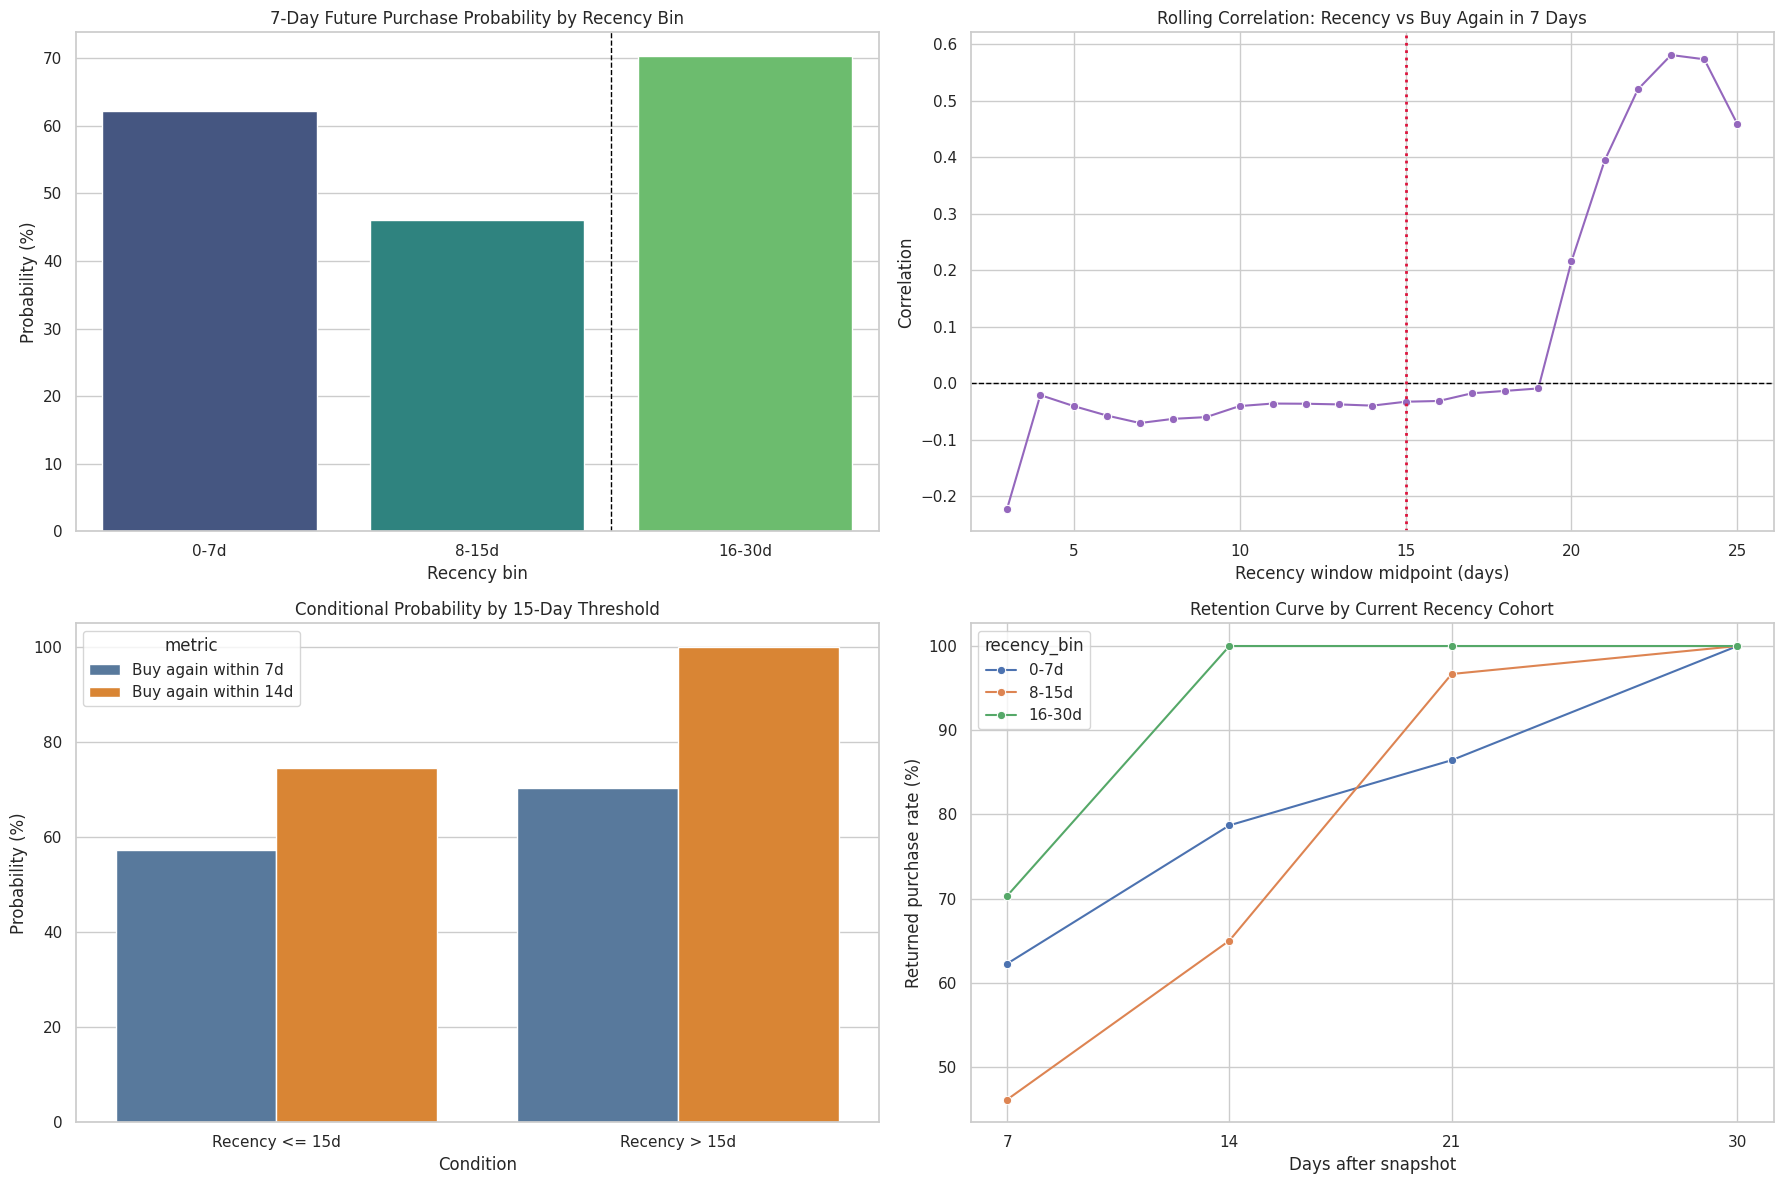

Recency bin summary:


,recency_bin,observations,avg_recency_days,avg_days_until_next_order,p_buy_again_7d_pct,p_buy_again_14d_pct,corr_recency_vs_buy_7d
0,0-7d,565468,3.056778,8.154598,62.283454,78.706841,-0.215847
1,8-15d,253237,11.067913,9.893199,46.148470,65.025648,-0.043239
2,16-30d,247092,22.738025,5.235115,70.338578,100.000000,0.578977


Conditional probability check at 15 days:


,condition,observations,p_buy_again_7d_pct,p_buy_again_14d_pct,avg_days_until_next_order
0,Recency <= 15d,818705,57.292676,74.475055,8.692371
1,Recency > 15d,247092,70.338578,100.000000,5.235115


Retention curve by recency cohort:


,recency_bin,return_rate_pct,days_after_snapshot
0,0-7d,62.283454,7
1,8-15d,46.148470,7
2,16-30d,70.338578,7
3,0-7d,78.706841,14
4,8-15d,65.025648,14
5,16-30d,100.000000,14
6,0-7d,86.444679,21
7,8-15d,96.678605,21
8,16-30d,100.000000,21
9,0-7d,100.000000,30


Recency threshold summary
- P(Buy again within 7 days | Recency <= 15) = 57.3%
- P(Buy again within 7 days | Recency > 15) = 70.3%
- Weakest short-term return band is 8-15d (46.1%).
- Strongest rolling negative relationship appears around 0-6d (corr = -0.22).
- In this dataset, 16-30d rebounds because many shoppers are entering their normal reorder cycle, so day 15 behaves more like an inflection point than a hard churn cliff.
- Use this together with segment, gap, and health-score views because Instacart inter-order gaps are capped near 30 days.


: 

In [ ]:
# --- Recency threshold diagnostics ---
RECENCY_ACTION_THRESHOLD = 15
EARLY_PURCHASE_WINDOW = 7
ALT_PURCHASE_WINDOW = 14
ROLLING_WINDOW_DAYS = 7
CURVE_HORIZONS = [7, 14, 21, 30]
recency_bin_order = ["0-7d", "8-15d", "16-30d"]


def safe_binary_corr(frame, value_col, binary_col):
    if frame.empty or frame[binary_col].nunique() < 2:
        return np.nan
    return frame[value_col].corr(frame[binary_col].astype(float))


# Rebuild prerequisites when this cell is run standalone.
if "df" not in globals():
    import instacart_quality.data_access as data_access_module

    fallback_root = PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd().resolve()
    fallback_sample = USE_SAMPLE if "USE_SAMPLE" in globals() else False
    df = data_access_module.load_customer_behavior_data(
        use_sample=fallback_sample,
        project_root=fallback_root,
    )

if "order_value" not in globals():
    order_value = (
        df.groupby(["user_id", "order_id", "order_date", "order_dow"], observed=False)
        .agg(order_value=("total_price", "sum"))
        .reset_index()
    )
    order_value["order_month"] = order_value["order_date"].dt.to_period("M").dt.to_timestamp()

if "latest_order_date" not in globals() or "trend_monthly" not in globals():
    latest_order_date = df["order_date"].max()
    monthly_kpis = (
        order_value.groupby("order_month", observed=False)
        .agg(active_customers=("user_id", "nunique"))
        .reset_index()
        .sort_values("order_month")
    )
    latest_month = latest_order_date.to_period("M").to_timestamp()
    exclude_partial_month = (
        latest_month == monthly_kpis["order_month"].max()
        and latest_order_date.day <= 7
    )
    trend_monthly = (
        monthly_kpis[monthly_kpis["order_month"] < latest_month].copy()
        if exclude_partial_month
        else monthly_kpis.copy()
    )

if "customer_health_state" not in globals():
    analysis_months = trend_monthly["order_month"].drop_duplicates().sort_values()
    month_calendar = pd.DataFrame({"order_month": pd.Index(analysis_months)})
    month_calendar["month_label"] = month_calendar["order_month"].dt.strftime("%Y-%m")
    month_calendar["month_end"] = month_calendar["order_month"] + pd.offsets.MonthEnd(1)

    all_users = order_value[["user_id"]].drop_duplicates()
    user_month_grid = (
        all_users.assign(key=1)
        .merge(month_calendar.assign(key=1), on="key")
        .drop(columns="key")
        .sort_values(["month_end", "user_id"])
        .reset_index(drop=True)
    )
    user_order_history = (
        order_value[["user_id", "order_date"]]
        .drop_duplicates()
        .sort_values(["order_date", "user_id"])
        .reset_index(drop=True)
    )
    customer_health_state = pd.merge_asof(
        user_month_grid,
        user_order_history,
        by="user_id",
        left_on="month_end",
        right_on="order_date",
        direction="backward",
    ).rename(columns={"order_date": "last_order_date_to_month_end"})
    customer_health_state["days_since_last_order"] = (
        customer_health_state["month_end"] - customer_health_state["last_order_date_to_month_end"]
    ).dt.days

future_order_history = (
    order_value[["user_id", "order_date"]]
    .drop_duplicates()
    .sort_values(["order_date", "user_id"])
    .reset_index(drop=True)
)

recency_future_eval = pd.merge_asof(
    customer_health_state.sort_values(["month_end", "user_id"]).reset_index(drop=True),
    future_order_history,
    by="user_id",
    left_on="month_end",
    right_on="order_date",
    direction="forward",
).rename(columns={"order_date": "next_order_after_snapshot"})

recency_future_eval = recency_future_eval[
    recency_future_eval["last_order_date_to_month_end"].notna()
].copy()
recency_future_eval["lookahead_complete"] = (
    recency_future_eval["month_end"] + pd.Timedelta(days=max(CURVE_HORIZONS)) <= latest_order_date
)
recency_future_eval["days_until_next_order"] = (
    recency_future_eval["next_order_after_snapshot"] - recency_future_eval["month_end"]
).dt.days
recency_future_eval = recency_future_eval[
    recency_future_eval["lookahead_complete"]
    & recency_future_eval["days_since_last_order"].between(0, 30)
].copy()
recency_future_eval["buy_again_7d"] = (
    recency_future_eval["days_until_next_order"].le(EARLY_PURCHASE_WINDOW).fillna(False)
)
recency_future_eval["buy_again_14d"] = (
    recency_future_eval["days_until_next_order"].le(ALT_PURCHASE_WINDOW).fillna(False)
)
recency_future_eval["recency_bin"] = pd.cut(
    recency_future_eval["days_since_last_order"],
    bins=[-1, 7, 15, 30],
    labels=recency_bin_order,
)

recency_bin_summary = (
    recency_future_eval.groupby("recency_bin", observed=False)
    .agg(
        observations=("user_id", "size"),
        avg_recency_days=("days_since_last_order", "mean"),
        avg_days_until_next_order=("days_until_next_order", "mean"),
        p_buy_again_7d_pct=("buy_again_7d", lambda s: 100 * s.mean()),
        p_buy_again_14d_pct=("buy_again_14d", lambda s: 100 * s.mean()),
    )
    .reindex(recency_bin_order)
    .reset_index()
)
recency_bin_corr = (
    recency_future_eval.groupby("recency_bin", observed=False)
    .apply(
        lambda g: safe_binary_corr(g, "days_since_last_order", "buy_again_7d"),
        include_groups=False,
    )
    .reindex(recency_bin_order)
    .rename("corr_recency_vs_buy_7d")
    .reset_index()
)
recency_bin_summary = recency_bin_summary.merge(recency_bin_corr, on="recency_bin", how="left")

rolling_corr_rows = []
for start_day in range(0, 30 - ROLLING_WINDOW_DAYS + 2):
    end_day = start_day + ROLLING_WINDOW_DAYS - 1
    subset = recency_future_eval[
        recency_future_eval["days_since_last_order"].between(start_day, end_day)
    ]
    rolling_corr_rows.append(
        {
            "window_label": f"{start_day}-{end_day}d",
            "window_mid": (start_day + end_day) / 2,
            "observations": len(subset),
            "buy_again_7d_pct": 100 * subset["buy_again_7d"].mean() if len(subset) else np.nan,
            "corr_recency_vs_buy_7d": safe_binary_corr(subset, "days_since_last_order", "buy_again_7d"),
        }
    )
rolling_corr = pd.DataFrame(rolling_corr_rows)
rolling_corr_plot = rolling_corr.dropna(subset=["corr_recency_vs_buy_7d"]).copy()

conditional_probability = pd.DataFrame(
    {
        "condition": [f"Recency <= {RECENCY_ACTION_THRESHOLD}d", f"Recency > {RECENCY_ACTION_THRESHOLD}d"],
        "observations": [
            recency_future_eval[recency_future_eval["days_since_last_order"] <= RECENCY_ACTION_THRESHOLD].shape[0],
            recency_future_eval[recency_future_eval["days_since_last_order"] > RECENCY_ACTION_THRESHOLD].shape[0],
        ],
        "p_buy_again_7d_pct": [
            100
            * recency_future_eval.loc[
                recency_future_eval["days_since_last_order"] <= RECENCY_ACTION_THRESHOLD,
                "buy_again_7d",
            ].mean(),
            100
            * recency_future_eval.loc[
                recency_future_eval["days_since_last_order"] > RECENCY_ACTION_THRESHOLD,
                "buy_again_7d",
            ].mean(),
        ],
        "p_buy_again_14d_pct": [
            100
            * recency_future_eval.loc[
                recency_future_eval["days_since_last_order"] <= RECENCY_ACTION_THRESHOLD,
                "buy_again_14d",
            ].mean(),
            100
            * recency_future_eval.loc[
                recency_future_eval["days_since_last_order"] > RECENCY_ACTION_THRESHOLD,
                "buy_again_14d",
            ].mean(),
        ],
        "avg_days_until_next_order": [
            recency_future_eval.loc[
                recency_future_eval["days_since_last_order"] <= RECENCY_ACTION_THRESHOLD,
                "days_until_next_order",
            ].mean(),
            recency_future_eval.loc[
                recency_future_eval["days_since_last_order"] > RECENCY_ACTION_THRESHOLD,
                "days_until_next_order",
            ].mean(),
        ],
    }
)

conditional_probability_long = conditional_probability.melt(
    id_vars=["condition", "observations"],
    value_vars=["p_buy_again_7d_pct", "p_buy_again_14d_pct"],
    var_name="metric",
    value_name="probability_pct",
)
conditional_probability_long["metric"] = conditional_probability_long["metric"].map(
    {
        "p_buy_again_7d_pct": "Buy again within 7d",
        "p_buy_again_14d_pct": "Buy again within 14d",
    }
)

retention_curve_by_recency = []
for horizon in CURVE_HORIZONS:
    horizon_curve = (
        recency_future_eval.groupby("recency_bin", observed=False)["days_until_next_order"]
        .apply(lambda s: 100 * s.le(horizon).mean())
        .reindex(recency_bin_order)
        .rename("return_rate_pct")
        .reset_index()
    )
    horizon_curve["days_after_snapshot"] = horizon
    retention_curve_by_recency.append(horizon_curve)
retention_curve_by_recency = pd.concat(retention_curve_by_recency, ignore_index=True)
retention_curve_by_recency = retention_curve_by_recency.dropna(subset=["return_rate_pct"])

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(
    data=recency_bin_summary,
    x="recency_bin",
    y="p_buy_again_7d_pct",
    hue="recency_bin",
    order=recency_bin_order,
    palette="viridis",
    dodge=False,
    ax=axes[0, 0],
)
if axes[0, 0].legend_ is not None:
    axes[0, 0].legend_.remove()
axes[0, 0].axvline(1.5, color="black", linestyle="--", linewidth=1)
axes[0, 0].set_title("7-Day Future Purchase Probability by Recency Bin")
axes[0, 0].set_xlabel("Recency bin")
axes[0, 0].set_ylabel("Probability (%)")

if rolling_corr_plot.empty:
    axes[0, 1].text(0.5, 0.5, "Not enough variation for rolling correlation", ha="center", va="center")
    axes[0, 1].set_axis_off()
else:
    sns.lineplot(
        data=rolling_corr_plot,
        x="window_mid",
        y="corr_recency_vs_buy_7d",
        marker="o",
        ax=axes[0, 1],
        color="tab:purple",
    )
    axes[0, 1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0, 1].axvline(RECENCY_ACTION_THRESHOLD, color="crimson", linestyle=":", linewidth=2)
    axes[0, 1].set_title("Rolling Correlation: Recency vs Buy Again in 7 Days")
    axes[0, 1].set_xlabel("Recency window midpoint (days)")
    axes[0, 1].set_ylabel("Correlation")

sns.barplot(
    data=conditional_probability_long,
    x="condition",
    y="probability_pct",
    hue="metric",
    palette=["#4C78A8", "#F58518"],
    ax=axes[1, 0],
)
axes[1, 0].set_title("Conditional Probability by 15-Day Threshold")
axes[1, 0].set_xlabel("Condition")
axes[1, 0].set_ylabel("Probability (%)")

sns.lineplot(
    data=retention_curve_by_recency,
    x="days_after_snapshot",
    y="return_rate_pct",
    hue="recency_bin",
    hue_order=recency_bin_order,
    marker="o",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Retention Curve by Current Recency Cohort")
axes[1, 1].set_xlabel("Days after snapshot")
axes[1, 1].set_ylabel("Returned purchase rate (%)")
axes[1, 1].set_xticks(CURVE_HORIZONS)

plt.tight_layout()
plt.show()

show_df(recency_bin_summary, title="Recency bin summary:")
show_df(conditional_probability, title="Conditional probability check at 15 days:")
show_df(
    retention_curve_by_recency,
    title="Retention curve by recency cohort:",
)

le_15 = conditional_probability.loc[0, "p_buy_again_7d_pct"]
gt_15 = conditional_probability.loc[1, "p_buy_again_7d_pct"]
weakest_bin = recency_bin_summary.loc[
    recency_bin_summary["p_buy_again_7d_pct"].idxmin(),
    "recency_bin",
]
strongest_bin = recency_bin_summary.loc[
    recency_bin_summary["p_buy_again_7d_pct"].idxmax(),
    "recency_bin",
]
if rolling_corr_plot.empty:
    lowest_corr_label = "N/A"
    lowest_corr_value = np.nan
else:
    lowest_corr_window = rolling_corr_plot.loc[
        rolling_corr_plot["corr_recency_vs_buy_7d"].idxmin()
    ]
    lowest_corr_label = lowest_corr_window["window_label"]
    lowest_corr_value = lowest_corr_window["corr_recency_vs_buy_7d"]

print("Recency threshold summary")
print(
    f"- P(Buy again within 7 days | Recency <= {RECENCY_ACTION_THRESHOLD}) = {le_15:.1f}%"
)
print(
    f"- P(Buy again within 7 days | Recency > {RECENCY_ACTION_THRESHOLD}) = {gt_15:.1f}%"
)
print(
    f"- Weakest short-term return band is {weakest_bin} "
    f"({recency_bin_summary.loc[recency_bin_summary['recency_bin'] == weakest_bin, 'p_buy_again_7d_pct'].iloc[0]:.1f}%)."
)
if pd.notna(lowest_corr_value):
    print(
        f"- Strongest rolling negative relationship appears around {lowest_corr_label} "
        f"(corr = {lowest_corr_value:.2f})."
    )
else:
    print("- Rolling correlation is unavailable in some windows because the outcome has little variation.")
print(
    f"- In this dataset, {strongest_bin} rebounds because many shoppers are entering their normal reorder cycle, "
    "so day 15 behaves more like an inflection point than a hard churn cliff."
)
print(
    "- Use this together with segment, gap, and health-score views because Instacart inter-order gaps are capped near 30 days."
)

## Habit Formation
1. วิเคราะห์ Insight: ทำไมต้อง 15 วัน?

    ช่วง 0-15 วัน (The Honeymoon Phase): ลูกค้าใหม่มีความตื่นเต้น (Novelty Effect) และกำลังทดลองใช้บริการ ช่วงนี้ Reorder Ratio มักจะสูงเพราะเขายังมี Intent ที่ชัดเจน

    จุด 15 วัน (The Chasm): หลังจากผ่านไป 2 สัปดาห์ ความตื่นเต้นเริ่มลดลง (Friction เริ่มชนะ Novelty) หากเราไม่สามารถทำให้การซื้อกลายเป็น "นิสัย" (Habit) ได้ในช่วงนี้ เขาจะหายไปเลย

    ถ้าเกิน 15 วันแล้วยังอยู่ (The Retained Zone): ถ้าลูกค้ายังมีการเคลื่อนไหวหรือเราดึงเขากลับมาได้หลัง 15 วัน มักแปลว่าเขาเริ่ม "ติด" (Sticky) หรือเห็น Value จริงๆ ของบริการเราแล้ว โอกาสเป็นลูกค้าประจำ (Loyal Customer) จะสูงขึ้นมาก

## สิ่งแนะนําที่ควรทํา 

2. การคาดการณ์ (Predictive Power)

ในทางกราฟหรือสถิติ เราสามารถพิสูจน์และใช้ประโยชน์จากเรื่องนี้ได้ผ่าน 2 เทคนิคครับ:

- Hazard Function: เป็นการวัด "โอกาสที่จะเลิก (Churn)" ณ เวลาใดเวลาหนึ่ง ถ้ากราฟ Hazard พุ่งสูงสุดที่ 15 วัน แล้วเริ่มลดลงหลังจากนั้น นั่นยืนยันสมมติฐานคุณว่า "ถ้าผ่าน 15 วันไปได้ ความเสี่ยงที่จะเลิกจะลดลง"

- Uplift Modeling: คุณสามารถทดลอง (A/B Test) ส่ง Notification หรือคูปองพิเศษในวันที่ 12-14 เพื่อ "ประคอง" ไม่ให้เขาร่วงหล่นในช่วงหน้าผา 15 วัน แล้วดูว่ากลุ่มที่ได้รับแรงกระตุ้นนี้มี LTV (Lifetime Value) สูงกว่ากลุ่มปกติหรือไม่

### 10) Conversion to Habit Rate by Order Depth

พลอตนี้ดูว่าเมื่อ `Recency` เปลี่ยนไป โอกาสที่ลูกค้าจะซื้อครั้งถัดไปภายใน `30 วัน` เปลี่ยนอย่างไร โดยแยกตามจำนวนออเดอร์สะสม

การแก้เวอร์ชันนี้ทำ 3 อย่างตรงตามข้อกังวล:
1. ใช้ **full order history** จาก `orders_with_dates` เพื่อให้เห็น cohort `1 order`, `2 orders`, และ `5+ orders` จริง
2. ปล่อยแกน Y แบบปกติ ไม่บีบไว้ที่ `95-101`
3. แยกกราฟ `30-day reference` ออกจาก `7-day practical proxy` เพราะใน Instacart ค่า inter-order gap ถูก **capped ที่ 30 วัน** ทำให้เส้น 30 วันมีแนวโน้มแบนเกือบทั้งหมดโดยโครงสร้างข้อมูลเอง

> สรุป: กราฟ 30 วันมีไว้เป็น **reference only** ส่วนกราฟ 7 วันคือกราฟที่ใช้ตีความเชิงธุรกิจได้จริง

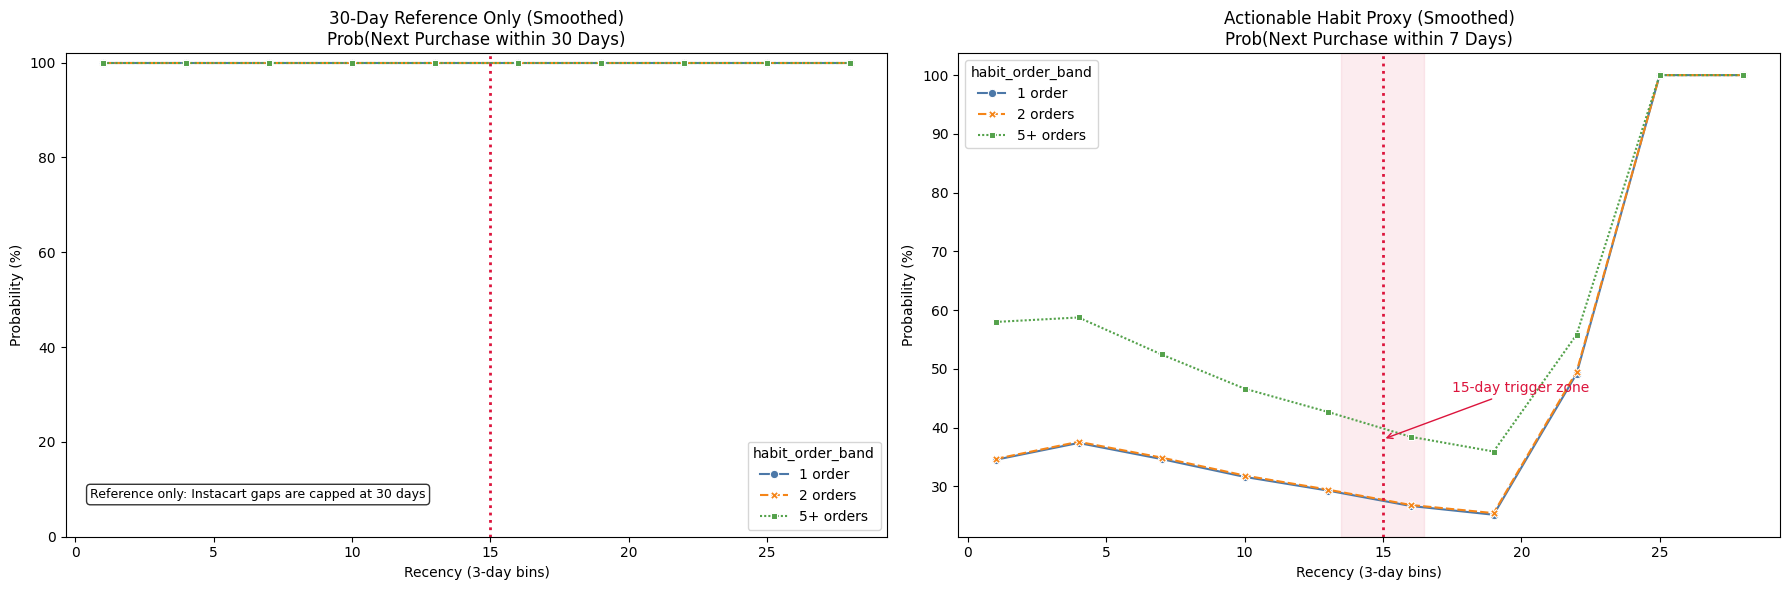

Habit-rate summary by order depth:


,habit_order_band,customers,order_transitions,avg_gap_to_next_order
0,1 order,203310,203310,15.560892
1,2 orders,203294,203294,15.506213
2,5+ orders,162400,2357681,9.981970


Smoothed habit-rate curve (3-day bins, observations > 50):


,habit_order_band,recency_bin_label,observations,prob_next_purchase_30d_pct,prob_next_purchase_7d_pct
0,1 order,0-2d,594083,100.0,34.532583
1,1 order,3-5d,528576,100.0,37.399530
2,1 order,6-8d,423474,100.0,34.659180
3,1 order,9-11d,347393,100.0,31.630283
4,1 order,12-14d,295226,100.0,29.306302
5,1 order,15-17d,247398,100.0,26.680042
6,1 order,18-20d,219089,100.0,25.184324
7,1 order,21-23d,188452,100.0,49.182528
8,1 order,24-26d,169777,100.0,100.000000
9,1 order,27-29d,150217,100.0,100.000000


15-day trigger snapshot by order depth:


,habit_order_band,trigger_prob_7d_pct
0,1 order,26.680042
1,2 orders,26.847693
2,5+ orders,38.456159


Conversion to habit-rate summary
- Fixed the cohort issue by using full order history; min observed order_number = 1, so 1-order and 2-order cohorts are now included.
- The curve is now smoothed into 3-day bins and filtered to observations > 50 to remove noisy tail spikes.
- The 30-day chart remains a reference plot only because Instacart inter-order gaps are capped at 30 days.
- Around the 15-day trigger zone, 7-day repeat probability is about 26.7% for 1 order, 26.8% for 2 orders, and 38.5% for 5+ orders.
- Business summary: day 15 is the practical intervention point; after that, short-term repeat intent is materially softer, especially for low-order cohorts.


In [6]:
# --- Conversion to habit rate by order depth (full order history, smoothed) ---
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import importlib

HABIT_WINDOW_DAYS = 30
HABIT_EARLY_WINDOW = 7
HABIT_BIN_DAYS = 3
MIN_OBSERVATIONS_TO_PLOT = 50
TRIGGER_DAY = 15
habit_band_order = ["1 order", "2 orders", "5+ orders"]
habit_palette = {
    "1 order": "#4C78A8",
    "2 orders": "#F58518",
    "5+ orders": "#54A24B",
}

if "show_df" not in globals():
    def show_df(df, title=None, n=10):
        if title:
            print(title)
        display(df.head(n))

project_root = PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd().resolve()
if not (project_root / "src").exists():
    for parent in [project_root, *project_root.parents]:
        if (parent / "src").exists() and (parent / "data").exists():
            project_root = parent
            break

if str(project_root / "src") not in __import__("sys").path:
    __import__("sys").path.insert(0, str(project_root / "src"))

import instacart_quality.data_access as data_access_module
importlib.reload(data_access_module)

use_sample_flag = USE_SAMPLE if "USE_SAMPLE" in globals() else False
orders_path = data_access_module.ensure_feature_table(
    "orders_with_dates",
    use_sample=use_sample_flag,
    project_root=project_root,
)
orders_all = pd.read_csv(orders_path, parse_dates=["order_date"])
orders_all = orders_all.sort_values(["user_id", "order_number", "order_date"]).copy()
orders_all["next_order_date"] = orders_all.groupby("user_id", observed=False)["order_date"].shift(-1)
orders_all["days_to_next_order"] = (
    orders_all["next_order_date"] - orders_all["order_date"]
).dt.days

habit_event_base = orders_all.dropna(subset=["days_to_next_order"]).copy()
habit_event_base = habit_event_base[habit_event_base["days_to_next_order"].between(1, 30)].copy()
habit_event_base["habit_order_band"] = np.select(
    [
        habit_event_base["order_number"].eq(1),
        habit_event_base["order_number"].eq(2),
        habit_event_base["order_number"].ge(5),
    ],
    habit_band_order,
    default="3-4 orders",
)
habit_event_base = habit_event_base[
    habit_event_base["habit_order_band"].isin(habit_band_order)
].copy()

habit_curve_rows = []
for recency_day in range(0, HABIT_WINDOW_DAYS):
    eligible = habit_event_base[habit_event_base["days_to_next_order"] > recency_day]
    for band in habit_band_order:
        subset = eligible[eligible["habit_order_band"] == band]
        if subset.empty:
            continue
        habit_curve_rows.append(
            {
                "recency": recency_day,
                "habit_order_band": band,
                "observations": len(subset),
                "prob_next_purchase_30d_pct": 100 * (subset["days_to_next_order"] <= recency_day + HABIT_WINDOW_DAYS).mean(),
                "prob_next_purchase_7d_pct": 100 * (subset["days_to_next_order"] <= recency_day + HABIT_EARLY_WINDOW).mean(),
            }
        )
habit_rate_curve = pd.DataFrame(habit_curve_rows)
habit_rate_curve = habit_rate_curve[habit_rate_curve["observations"] > MIN_OBSERVATIONS_TO_PLOT].copy()

habit_rate_curve["recency_bin_start"] = (
    habit_rate_curve["recency"] // HABIT_BIN_DAYS
) * HABIT_BIN_DAYS
habit_rate_curve["recency_bin_label"] = habit_rate_curve.apply(
    lambda row: f"{int(row['recency_bin_start'])}-{int(min(row['recency_bin_start'] + HABIT_BIN_DAYS - 1, HABIT_WINDOW_DAYS - 1))}d",
    axis=1,
)
habit_rate_curve["recency_mid"] = habit_rate_curve["recency_bin_start"] + (HABIT_BIN_DAYS - 1) / 2

habit_rate_curve_binned = (
    habit_rate_curve.groupby(["habit_order_band", "recency_bin_start", "recency_bin_label", "recency_mid"], observed=False)
    .agg(
        observations=("observations", "sum"),
        prob_next_purchase_30d_pct=("prob_next_purchase_30d_pct", "mean"),
        prob_next_purchase_7d_pct=("prob_next_purchase_7d_pct", "mean"),
    )
    .reset_index()
    .sort_values(["habit_order_band", "recency_bin_start"])
)

habit_rate_summary = (
    habit_event_base.groupby("habit_order_band", observed=False)
    .agg(
        customers=("user_id", "nunique"),
        order_transitions=("order_id", "count"),
        avg_gap_to_next_order=("days_to_next_order", "mean"),
    )
    .reindex(habit_band_order)
    .reset_index()
)

trigger_bin = habit_rate_curve_binned[
    habit_rate_curve_binned["recency_bin_start"].between(TRIGGER_DAY - (HABIT_BIN_DAYS - 1), TRIGGER_DAY)
].copy()
trigger_snapshot = (
    trigger_bin.groupby("habit_order_band", observed=False)
    .agg(trigger_prob_7d_pct=("prob_next_purchase_7d_pct", "mean"))
    .reindex(habit_band_order)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(
    data=habit_rate_curve_binned,
    x="recency_mid",
    y="prob_next_purchase_30d_pct",
    hue="habit_order_band",
    hue_order=habit_band_order,
    style="habit_order_band",
    style_order=habit_band_order,
    markers=True,
    dashes=True,
    palette=habit_palette,
    ax=axes[0],
)
axes[0].axvline(TRIGGER_DAY, color="crimson", linestyle=":", linewidth=2)
axes[0].set_title("30-Day Reference Only (Smoothed)\nProb(Next Purchase within 30 Days)")
axes[0].set_xlabel("Recency (3-day bins)")
axes[0].set_ylabel("Probability (%)")
axes[0].set_ylim(0, 102)
axes[0].text(
    0.03,
    0.08,
    "Reference only: Instacart gaps are capped at 30 days",
    transform=axes[0].transAxes,
    fontsize=9,
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8},
)

sns.lineplot(
    data=habit_rate_curve_binned,
    x="recency_mid",
    y="prob_next_purchase_7d_pct",
    hue="habit_order_band",
    hue_order=habit_band_order,
    style="habit_order_band",
    style_order=habit_band_order,
    markers=True,
    dashes=True,
    palette=habit_palette,
    ax=axes[1],
)
axes[1].axvline(TRIGGER_DAY, color="crimson", linestyle=":", linewidth=2, label="15-day trigger")
axes[1].axvspan(TRIGGER_DAY - 1.5, TRIGGER_DAY + 1.5, color="crimson", alpha=0.08)
axes[1].set_title("Actionable Habit Proxy (Smoothed)\nProb(Next Purchase within 7 Days)")
axes[1].set_xlabel("Recency (3-day bins)")
axes[1].set_ylabel("Probability (%)")
axes[1].annotate(
    "15-day trigger zone",
    xy=(TRIGGER_DAY, habit_rate_curve_binned["prob_next_purchase_7d_pct"].median()),
    xytext=(TRIGGER_DAY + 2.5, habit_rate_curve_binned["prob_next_purchase_7d_pct"].median() + 8),
    arrowprops={"arrowstyle": "->", "color": "crimson"},
    color="crimson",
    fontsize=10,
)

plt.tight_layout()
plt.show()

show_df(habit_rate_summary, title="Habit-rate summary by order depth:")
show_df(
    habit_rate_curve_binned[[
        "habit_order_band",
        "recency_bin_label",
        "observations",
        "prob_next_purchase_30d_pct",
        "prob_next_purchase_7d_pct",
    ]],
    title="Smoothed habit-rate curve (3-day bins, observations > 50):",
    n=30,
)
show_df(trigger_snapshot, title="15-day trigger snapshot by order depth:", n=10)

min_order_number = int(orders_all["order_number"].min())
trigger_1 = trigger_snapshot.loc[trigger_snapshot["habit_order_band"] == "1 order", "trigger_prob_7d_pct"].iloc[0]
trigger_2 = trigger_snapshot.loc[trigger_snapshot["habit_order_band"] == "2 orders", "trigger_prob_7d_pct"].iloc[0]
trigger_5 = trigger_snapshot.loc[trigger_snapshot["habit_order_band"] == "5+ orders", "trigger_prob_7d_pct"].iloc[0]

print("Conversion to habit-rate summary")
print(
    f"- Fixed the cohort issue by using full order history; min observed order_number = {min_order_number}, so 1-order and 2-order cohorts are now included."
)
print(
    f"- The curve is now smoothed into {HABIT_BIN_DAYS}-day bins and filtered to observations > {MIN_OBSERVATIONS_TO_PLOT} to remove noisy tail spikes."
)
print(
    "- The 30-day chart remains a reference plot only because Instacart inter-order gaps are capped at 30 days."
)
print(
    f"- Around the 15-day trigger zone, 7-day repeat probability is about {trigger_1:.1f}% for 1 order, {trigger_2:.1f}% for 2 orders, and {trigger_5:.1f}% for 5+ orders."
)
print(
    "- Business summary: day 15 is the practical intervention point; after that, short-term repeat intent is materially softer, especially for low-order cohorts."
)

## สรุป Insight เพิ่ม
Habit Gap: กลุ่ม 5+ orders (เส้นเขียว) มีความน่าจะเป็นสูงกว่ากลุ่ม 1-2 orders เกือบ 2 เท่า ในช่วงแรก นั่นคือ "ความแข็งแกร่งของ Habit"

The 15-Day Cliff: สังเกตเส้นสีเขียวครับ มันดิ่งลงชันมากจาก 60% เหลือ 40% เมื่อถึงวันที่ 15

    Insight: ต่อให้เป็นลูกค้าประจำ (5+ orders) ถ้าปล่อยให้หายไปถึง 15 วัน ความ "เหนียว" ของเขาจะหายไปจนเกือบเท่าลูกค้าใหม่

15-day Trigger Zone: นี่คือจุดที่คุณทำถูกมาก การมาร์กสีชมพูไว้บอกว่า "นี่คือวินาทีสุดท้ายที่จะดึง Habit กลับมาได้"